# Weak Supervision


## Introduction

The idea behind **weak supervision** is that for each data point there is a *latent true label* that is inaccessible to us even during training, instead we utilize weak signals from user-defined **labeling functions** (LF). The material here is based on the **data programming** approach to weak supervision using LFs described in [@data-programming]. Here we extend to the multi-class case where the generative model has entries of the entire confusion matrix as learnable parameters.

LFs can be thought of as heuristic rules that can be applied to a large subset of the data. In case the LF is not applicable, then the function simply abstains from making a prediction. Note that this is a realistic scenario, it's easier to describe rules than to manually annotate a large number of data points. LFs provide noisy, but potentially cost-effective labels, which can be used to train discriminative models. 

![**Weak supervision training pipeline**. The third image is flipped (i.e. the flow of prediction is right to left.) 
These two tasks will be implemented in this notebook. [Source](https://cs.brown.edu/people/sbach/files/bach-icml17-slides.pdf)](./img/01-weak-supervision-pipeline.png)

### Labeling Functions

Suppose we have a large corpus of text (e.g. the [IMDB Movie Reviews dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)) that we want to classify as either positive or negative. Our goal is to predict labels for this dataset (with somewhat high accuracy) using only a minimal set of labeled examples. The ff. is an example of a positive movie review:

> We always watch American movies with their particular accents from each region (south, west, etc). We have the same here. All foreign people must to watch this movie and need to have a open mind to accept another culture, besides American and European almost dominate the cinematographic industry. <br><br> This movie tell us about a parallel world which it isn’t figured even for those who live in a big city like São Paulo. All actors are improvising and they are very realistic. The camera give us an idea of their confuse world, the loneliness of each character and invite us to share their world. <br><br>It’s a real great movie and worst a rent even have it at home.

On the other hand, a negative movie review can look like:

> I watch lots of scary movies (or at least they try to be) and this has to be the worst if not 2nd worst movie I have ever had to make myself try to sit through. I never knew the depths of Masacism until I rented this piece of moldy cheese covered in a used latex contraceptive. I am a fan of Julian Sans, but this is worse than I would hope for him.<br /><br />On the other hand the story was promising and I was intrigued...for the first minute and a half while the credits rolled and I had yet to see what pain looked like first hand. Perhaps there are some viewers out there that enjoyed this and can point me in the right direction, but then again I know of those viewers who understand if not commemorate me, especially when we had to turn the video off, and that simply is NOT done with our watching (we had to make one exception obviously). <br /><br />If it were up for a remake, I'd give it a chance so long as they had at most 1% of the original incorporated into it. That's all.

Manually labeling thousands of reviews is expensive (and doesn't scale well, i.e. linear), instead we can write heuristic rules called **labeling functions** (LF) primarily based on domain expertise or small observed examples. LFs scale well since it can be applied to a dataset in one sweep. Each LF inspects a review and returns `+1` (positive), `-1` (negative), or `0` (abstain). LFs can exploit many kinds of signals. Here we consider word counts, explicit ratings, viewing behavior, or comparative language:

In [1]:
K = 2
ABSTAIN = -1

def lf_sentiment_words(text):
    text = text.lower()
    pos_count = sum(1 for w in ["great", "love", "amazing", "fun"] if w in text)
    neg_count = sum(1 for w in ["bad", "waste", "boring", "stupid"] if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN

def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN

def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower:
        return 0
    return ABSTAIN

Consider these example reviews and notice how each LF can be fooled or simply silent:

In [2]:
review = "I've watched this twice already and couldn't stop watching — the pacing is superb."

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")          # abstain: no lexicon words match
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")       # "couldn't stop watching" phrase present
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")    # abstain: no comparative phrases match

lf_sentiment_words        -1
lf_viewing_experience      1
lf_comparative_sentiment  -1


The ff. shows an issue with keyword matching where sense of negation is not captured  (e.g. double negative):

In [3]:
review = "It's ok, not amazing but not worse than anything I've seen this year."

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")          # captures "amazing" even when negated
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")       # abstain: no viewing experience phrase present
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")    # negative: "worse than" even if negated

lf_sentiment_words         1
lf_viewing_experience     -1
lf_comparative_sentiment   0


All abstain despite clear negative:

In [4]:
review = """
This movie is an absolute DISASTER. Two hours of my life I'll never get back.
The plot makes zero sense, the acting is wooden, and the dialogue sounds like
it was written by a toddler. Every scene drags on forever. I've seen better
cinematography in a high school project. The sound mixing is atrocious. Zero stars.
"""

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")

lf_sentiment_words        -1
lf_viewing_experience     -1
lf_comparative_sentiment  -1


:::{.callout-tip}
LFs are  **iteratively refined** in practice: we inspect disagreements between LFs, compare against any available ground truth, and consult domain knowledge. Since LFs are user-defined heuristics, they require some expertise and data exploration to be effective. This requires substantial effort and (from experience) can even be scoped as one project under a team of annotators.

Since human annotation and cross-checking multiple LF outputs is prohibitive, LLMs can also serve as LFs: instead of hand-writing heuristics, you prompt a model to generate heuristics for a labeling function. This is a form of **knowledge distillation**: [the LLM's broad world knowledge gets compressed into a smaller, faster model via the weak supervision pipeline]{.mark} rather than through soft targets directly. At the very extreme, an LLM itself can directly be an LF[^llm_funcs]:

```python
def lf_llm(text):
    # can engineer abstention tendency by prompting
    response = client.chat.completions.create(...)
    return 1 if "positive" in response else 0 if "negative" in response else ABSTAIN
```

The [generative model](/notebooks/tooling/10-weak-supervision.html#basic-theory) (discussed below) still earns its keep here, since LLM-based LFs can have systematic biases that confusion matrix estimation helps correct. Cost efficiency is the main motivation: pay for LLM inference on a small subset, then train on the full dataset using the resulting noisy labels. This can be more cost-effective over performing LLM inference at scale. Moreover, multiple LFs can be created from a single LLM by varying the prompt — different phrasings, chain-of-thought vs. few-shot, and so on, giving the model more signal to work with.
:::

[^llm_funcs]: See [Text-to-LoRA](https://arxiv.org/abs/2506.06105). Also the [ProgramAsWeights](https://programasweights.readthedocs.io/en/latest/) project which compiles an LLM into task-specific runnable local functions.

### LF parameters

A labeling function is characterized by its **coverage** (fraction of inputs where it does not abstain) and its **F1 score** on non-abstaining inputs. For the IMDB task, a full set of seven LFs has the following profile (calculated on actual data):

| LF | Coverage | F1 |
| :-: | :-: | :-: |
| `lf_strong_sentiment` | 0.41 | 0.881 |
| `lf_sentiment_words` | 0.69 | 0.746 |
| `lf_rating_mention` | 0.02 | 0.812 |
| `lf_viewing_experience` | 0.01 | 0.800 |
| `lf_comparative_sentiment` | 0.01 | 0.711 |
| `lf_recommendation` | 0.11 | 0.798 |
| `lf_exclamation_sentiment` | 0.05 | 0.811 |

[There is a natural trade-off:]{.underline} LFs with broad coverage (like `lf_sentiment_words`) tend to have lower F1, while high-F1 LFs fire on fewer reviews (`lf_strong_sentiment` is a notable exception). The full definitions of these LFs and their application to IMDB data appear in the [application section](#application-imdb-movie-reviews) at the end of this notebook.

:::{.callout-note}
We generally do not have access to true labels for a representative sample of our dataset (or at best have access to a small labeled subset). Hence, even estimating the accuracy and coverage of our LFs is not possible. The following sections will deal with algorithms for estimating these parameters as well as training a machine learning model with noisy labels.
:::

In practice, the generative model performs at roughly the F1 of the best LFs, modulated by their coverage. The ideal scenario is a set of **conditionally independent** LFs — ones that fire on different subsets of the data and make mistakes on different examples. In that case, the generative model can ensemble them toward higher F1 than any single LF alone, since other LFs compensate for the gaps of one.

## Basic theory


For simplicity, we will limit our presentation to binary classification, although the method extends to the multiclass setting. For each data point $\textbf{\textsf{x}} \in \mathcal{X},$ the latent true label is $y \in \mathcal{Y} = \{0, 1, \ldots, K-1\}$. Suppose we have $N$ **labeling functions** $\lambda_j\colon \mathcal{X} \to \mathcal{Y} \cup \{-1\},$ where $-1$ denotes **abstention**. Given $M$ data points $\textbf{\textsf{x}}_i,$ we obtain an $M \times N$ matrix of LF outputs $\Lambda_{ij} = \lambda_j(\textbf{\textsf{x}}_i)$.

We write $\Lambda$ for the random variable representing LF outputs and $\lambda_\textbf{\textsf{x}}$ for the realized output vector of a specific input. Our first step is to estimate the joint distribution $p_\Phi(\lambda, y)$ as well as the marginal $p_\Phi(\Lambda) = \prod_{i=1}^M p(\lambda_{\textbf{\textsf{x}}_i}).$ We do MLE to find parameters $\hat{\Phi}$ that maximize the log-likelihood of the marginal 
$p_\Phi(\Lambda)$ of the observed LF outputs. See [below](/notebooks/tooling/10-weak-supervision.html#generative-model). This lets us calculate[^bayes]:

$$
\boxed{
    p_{\hat{\Phi}}(y \mid  \lambda_\textbf{\textsf{x}}) = \frac{p_{\hat{\Phi}}( y,\,  \lambda_\textbf{\textsf{x}})}{p_{\hat{\Phi}}( \lambda_\textbf{\textsf{x}})} = \frac{p_{\hat{\Phi}}( \lambda_\textbf{\textsf{x}} \mid y)\, p_y}{\sum_{y'=0}^{K-1} p_{\hat{\Phi}}(\lambda_\textbf{\textsf{x}} \mid y')\, p_{y'}}
}
$$ 

for any $y = 0, \ldots, K-1$ and any input $\textbf{\textsf{x}}.$ Given this, we perform **noise-aware training** (NAT) of a classifier $f_\Theta$ by minimizing the following loss:

$$
\boxed{
    \mathcal{L}_{\text{clf}}(\Theta) = 
    -\frac{1}{M}\sum_{i=1}^M \sum_{y=0}^{K-1} 
    {p_{\hat{\Phi}}(y \mid  \lambda_{\textbf{\textsf{x}}_i})} \cdot 
    \log \text{Softmax}(f_\Theta(\textbf{\textsf{x}}_i))_y
}
$$

where the sum over $y$ is the soft cross-entropy loss. This looks like the usual loss, except we don't have a single label. All labels contribute weighted by the probability of the label given the LF outputs of the input. The key insight is that the generative model is blind to the input features $\textbf{\textsf{x}}$ — it only sees LF outputs. Hence, we train on *every* candidate label, using the posterior $p_{\hat{\Phi}}(y \mid \lambda_{\textbf{\textsf{x}}_i})$ to steer how much each contributes to the gradient. As training progresses, $f_\Theta$ learns feature-to-label mappings that are simultaneously good classifiers *and* consistent with the LF-derived posterior — becoming confident on inputs where the generative model alone cannot be.

[^bayes]: While we need $p_{\hat{\Phi}}(y \mid  \lambda_\textbf{\textsf{x}})$ for training, what we have access to is the reverse: $p_{\hat{\Phi}}(\lambda_\textbf{\textsf{x}} \mid y)$ which we estimate by performing MLE on the LF outputs based on *all* targets (since we don't know which is the real one).

:::{.callout-note}
Each combination of $N$ LF outputs defines one of $3^N$ patterns, and the generative model assigns the same soft label to all points sharing a pattern. Exponential growth helps: 7 LFs yield $3^7 = 2{,}187$ bins. So this discretizes the space, and we rely on the hypothesis that points in the same bin share a label distribution for sufficiently large $N$ (which we hope to be not too large).
:::

### Generative model

Each LF has its own [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) showing how its outputs relate to the true labels. For instance, `lf_sentiment_words` has asymmetric accuracy — it is much better at identifying positive reviews than negative ones:

In [5]:
#| output: false
import re
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

ds = load_dataset("imdb")["train"].shuffle(seed=RANDOM_SEED).select(range(1000))
ds_texts = ds["text"]
ds_label = ds["label"]  # {0, 1}

In [6]:
from sklearn.metrics import confusion_matrix as cm

y = np.array(ds_label)
out = np.array([lf_sentiment_words(t) for t in ds_texts])
F = out != ABSTAIN
label = y[F]
preds = out[F]

conf = cm(label, preds, labels=[0, 1])
df = pd.DataFrame(conf, index=["y=0 (neg)", "y=1 (pos)"], columns=["pred=0", "pred=1"])
df["abstain"] = [sum(y[~F] == 0).item(), sum(y[~F] == 1).item()]
df

,pred=0,pred=1,abstain
y=0 (neg),166,135,206
y=1 (pos),25,291,177


Observe that this can be converted to conditional probabilities given $y.$ Let's call the resulting matrix $\mathbf{C}^{(j)} \in [0, 1]^{K \times (K + 1)}$:

In [7]:
df / df.sum(axis=1).values.reshape(-1, 1)

,pred=0,pred=1,abstain
y=0 (neg),0.327416,0.266272,0.406312
y=1 (pos),0.050710,0.590264,0.359026


[This is precisely what the generative model will learn from input data.]{.mark} To see this, consider an input $\textbf{\textsf{x}}$, we get LF outputs $\lambda_\textbf{\textsf{x}} \in [-1, 0, \ldots, K-1]^N.$ The marginal probability of this output vector is then:

$$
\boxed{p(\lambda_\textbf{\textsf{x}} ) = \sum_y  p_{y} \cdot p_{{\Phi}}(\lambda_\textbf{\textsf{x}} \mid y) = \sum_{y} p_y \cdot \prod_j C^j_{y, \lambda_j}}.
$$

Here we have to provide the **prior distribution** since the labels are censored. Also, we assume that the LF outputs are [conditionally independent]{.underline} given the true label. Note that the rows of $\mathbf{C}^{j}$ sum to 1, so our network will have logits of shape $K \times (K + 1)$ with entries ranging over $\mathbb{R}$; we will later apply softmax later along the rows. Finally, our goal is to perform MLE on $\Phi = \{\mathbf{C}^1, \ldots, \mathbf{C}^N\}$ by minimizing over the dataset:

$$
\boxed{
    \mathcal{L}_{\text{gen}}(\Phi) = \frac{1}{M}\sum_{i=1}^M -\log \left( 
        \sum_{y=0}^{K-1} p_y \cdot \prod_{j=1}^N C^j_{y,\, \Lambda_{ij}} 
    \right)
}.
$$


:::{.callout-note}
**Why model $p(\Lambda \mid Y)$ rather than $p(Y \mid \Lambda)$ directly?** Because the forward direction &mdash; how each LF behaves given a true label &mdash; is what we can decompose per-LF and estimate from unlabeled data. Each LF has its own confusion matrix independent of the others. Bayes' rule then gives us the posterior we actually need.
:::

:::{.callout-tip}
In practice, to avoid underflow with large number of LFs, we implement this using the $\text{LogSumExp}$ trick (e.g. with [`torch.logsumexp`](https://docs.pytorch.org/docs/stable/generated/torch.logsumexp.html)) as:

$$
{\log p(\lambda_\textbf{\textsf{x}}) = \log \sum_y \exp\!\left(\log p_y + \sum_j \log C^j_{y,\,\lambda_j}\right)}
$$

so that

$$
{
    \mathcal{L}_{\text{gen}}(\Phi) = -\frac{1}{M}\sum_{i=1}^M \log \sum_{y=0}^{K-1} \exp\!\left(\log p_y + \sum_{j=1}^N \log C^j_{y,\,\Lambda_{ij}}\right)
}.
$$

Finally, the soft target probability is given by:

$$
{
    p_{\hat{\Phi}}(y \mid \lambda_\textbf{\textsf{x}}) = \exp\Bigg(\log p_y + \sum_j \log C^j_{y,\,\lambda_j} - \log \sum_{y'} \exp\!\left(\log p_{y'} + \sum_j \log C^j_{y',\,\lambda_j}\right)\Bigg).
}
$$
:::

### Code implementation

For convenience, we let the elements of $\mathbf{C}^j$ be real numbers. Then, for each $j$, the confusion confusion matrix of the LF is obtained by taking the softmax along `dim=1` (i.e. conditioned on the target which is indexed in `dim=0`). We stack these along the third dimension so that we get a tensor $\mathbf{C}$ of shape $(K, K + 1, N).$ Since softmax is shift-invariant, we can initialize the abstain logits as $C_{y, K} = 0$ for all $y$, and derive its value from  non-abstain logits. This also makes it explicit that we have $K$ free parameters along a row.

In [8]:
import torch
torch.manual_seed(1)

K = 2
n = 4

# C[y, k, j] := P(λ_j = k | Y = y)
# C_logits is the unnormalized log-probs, which we optimize with gradient descent.
C_logits = torch.randn(K, K + 1, n)
C_logits[:, -1, :] = 0
C = torch.softmax(C_logits, dim=1)

print("Confusion matrix shape:", C.shape)
print(C)
print(C.sum(dim=1).numpy().sum())   # ~8 (2 targets x 4 LFs)

Confusion matrix shape: torch.Size([2, 3, 4])
tensor([[[0.1025, 0.2342, 0.2743, 0.1428],
         [0.4263, 0.2697, 0.1981, 0.1429],
         [0.4712, 0.4960, 0.5276, 0.7143]],

        [[0.4422, 0.0792, 0.2385, 0.1015],
         [0.1731, 0.5370, 0.4328, 0.7616],
         [0.3847, 0.3838, 0.3287, 0.1369]]])
8.0


We index into the confusion matrix using the LF output matrix. Class labels $\{0, \ldots, K-1\}$ map to the first $K$ columns, and abstain ($K$) maps to the last column. No remapping needed:

In [9]:
# Example LF output matrix: values in {0, 1, ..., K} where K = abstain
L = torch.tensor([
    [0, K,  1,  1],
    [1, 0,  0,  K],
])

# P(L | y=1): for each instance i and LF j, look up C[y=1, L[i,j], j]
y = 1
C[y, L, torch.arange(n)]  # shape: (m, n)

tensor([[0.4422, 0.3838, 0.4328, 0.7616],
        [0.1731, 0.0792, 0.2385, 0.1369]])

The product across LFs gives the conditional likelihood of the observed LF outputs for a given true label:

In [10]:
# P(Λ_i | y) = prod_j C[y, Λ_{ij}, j]
for y in range(K):
    probs = C[y, L, torch.arange(n)]  # (m, n)
    print(f"P(Λ | y={y}):", probs.prod(dim=1))

P(Λ | y=0): tensor([0.0014, 0.0196])
P(Λ | y=1): tensor([0.0560, 0.0004])


The marginal probability of the two LF outputs over the latent label:

In [11]:
py = torch.tensor([0.5, 0.5])  # class prior

p_marginal = sum(
    py[y] * C[y, L, torch.arange(n)].prod(dim=1)
    for y in range(K)
)

print("P([Λ0, Λ1]):", p_marginal)

P([Λ0, Λ1]): tensor([0.0287, 0.0100])


Finally, the marginal probability of the sample $p_{\Phi}(\Lambda).$ Because we generally have $M \gg 1$ terms with values in $[0, 1]$, we use $\log$ to avoid underflow:

In [12]:
print("     p(Λ):", p_marginal.prod().item())
print("-log p(Λ):", -torch.log(p_marginal).sum().item())

     p(Λ): 0.00028718687826767564
-log p(Λ): 8.155377388000488


## Toy experiments

In [13]:
#| output: false
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
import pandas as pd

from notebooks.plot import set_format
set_format("svg")

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

### Simulated LFs

Generating a toy dataset. Also setting the prior label probabilities:

In [14]:
m = 10000
K = 2
LABEL_PROBS = {0: 0.40, 1: 0.60}
y_true = np.random.choice([0, 1], size=m, p=[LABEL_PROBS[0], LABEL_PROBS[1]])

s = 2 * torch.pi * torch.rand(m, 1)
r = 0.5 * torch.tensor(y_true, dtype=torch.float32).view(-1, 1)  # 0 -> r=0, 1 -> r=0.5
x = torch.cat([r * torch.cos(s), r * torch.sin(s)], dim=1) + 0.05 * torch.randn(m, 2)

t = np.linspace(0, 2*np.pi, 100)
x0 = 0.5 * np.cos(t)
x1 = 0.5 * np.sin(t)
x_neg = x[torch.where(torch.tensor(y_true) == 0)]
x_pos = x[torch.where(torch.tensor(y_true) == 1)]

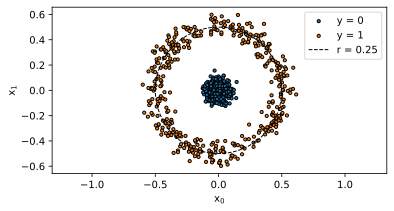

In [15]:
#| code-fold: true
def plot_dataset(x_neg, x_pos):
    m = len(x_neg)
    limit = m // 10
    plt.figure(figsize=(6, 3))
    plt.scatter(x_neg[:limit, 0], x_neg[:limit, 1], s=10.0, edgecolor="k", color="C0", label="y = 0")
    plt.scatter(x_pos[:limit, 0], x_pos[:limit, 1], s=10.0, edgecolor="k", color="C1", label="y = 1")
    plt.plot(x0, x1, color='black', linewidth=1, linestyle='dashed', label="r = 0.25")
    plt.xlabel("x$_0$")
    plt.ylabel("x$_1$")
    plt.legend()
    plt.axis("equal")

plot_dataset(x_neg, x_pos)

**Figure.** Below we use $r = 0.25$ as basis for synthetic LFs.

Note that radius less than 0.25 determines the label as $y = 0$ (with high probability):

In [16]:
# radius >= 0.25 -> class 1, else class 0
((torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long().numpy() == y_true).mean()

np.float64(1.0)

We use this to write simulated LFs with given parameters:

In [17]:
def lf_sim(coverage, accuracy):
    def predict(x):
        m = x.shape[0]
        y = (torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long()  # 0 or 1
        abstain_mask = torch.rand(m) >= coverage
        flip_mask = torch.rand(m) >= accuracy
        y[flip_mask] = 1 - y[flip_mask]         # flip label
        y[abstain_mask] = ABSTAIN               # -1
        return y
    return predict

# example
p = lf_sim(0.3, 0.8)(x).numpy()
fired = p != ABSTAIN
print("cov: ", fired.mean())
print("acc: ", (p[fired] == y_true[fired]).mean())
print("acc (y=0):", (p[fired & (y_true == 0)] == y_true[fired & (y_true == 0)]).mean())
print("acc (y=1):", (p[fired & (y_true == 1)] == y_true[fired & (y_true == 1)]).mean())

cov:  0.2993
acc:  0.7945205479452054
acc (y=0): 0.7960848287112561
acc (y=1): 0.7934352009054896


Initializing the empirical LF matrix for display. Some LFs have fairly low F1 on their covered examples:

In [18]:
lf_params = [(0.30, 0.75), (0.50, 0.65), (0.40, 0.70), (0.20, 0.80), (0.25, 0.90)]
labeling_funcs = [lf_sim(*param) for param in lf_params]

df = pd.DataFrame({"y": y_true})
df["x0"] = x[:, 0].numpy()
df["x1"] = x[:, 1].numpy()
for j, lf in enumerate(labeling_funcs):
    df[f"LF{j + 1}"] = lf(x).int().numpy()

print(df.shape)
df.head()

(10000, 8)


,y,x0,x1,LF1,LF2,LF3,LF4,LF5
0,1,-0.599245,0.044822,-1,1,-1,-1,-1
1,1,0.045224,-0.489432,-1,-1,0,-1,-1
2,1,0.367845,0.195856,-1,1,0,1,-1
3,1,0.345199,0.440180,-1,-1,-1,-1,-1
4,1,-0.138734,0.433529,1,1,-1,-1,-1


**Data split and LF matrix.** We split the data 80-20 for evaluation and precompute the LF output matrix $\Lambda$ for each split. Since `lf_sim` is stochastic (each call generates a fresh random sample), we call each LF once per split and store the results:

In [19]:
# 80-20
SPLIT_RATIO = 0.80
m = x.shape[0]

x_train = x[:int(SPLIT_RATIO * m)]
x_valid = x[int(SPLIT_RATIO * m):]
y_train = torch.tensor(y_true[:int(SPLIT_RATIO * m)])
y_valid = torch.tensor(y_true[int(SPLIT_RATIO * m):])

def build_L(labeling_funcs, x):
    """Build LF output matrix from labeling functions. Shape: (m, N)."""
    return torch.stack([lf(x) for lf in labeling_funcs], dim=1).long()

L_train = build_L(labeling_funcs, x_train)
L_valid = build_L(labeling_funcs, x_valid)
print(f"L_train: {L_train.shape}, L_valid: {L_valid.shape}")

L_train: torch.Size([8000, 5]), L_valid: torch.Size([2000, 5])


### Generative model training

:::{.callout-note}
We train the generative model with SGD and full-batch gradient descent. The logits are [**warm-started** with a diagonal preference]{.mark} (`logits[y, y, :] += 1.0`) to encourage the model to assign higher probability to the correct class initially. This bias resulted in significantly better performance.
:::

In [20]:
class GenModel:
    def __init__(self, num_classes: int, num_lfs: int, class_prior: dict = None):
        self.N = num_lfs
        self.K = num_classes
        py = [1.0 / self.K] * self.K if class_prior is None else [class_prior[k] for k in range(self.K)]
        self.py = torch.tensor(py, dtype=torch.float32)  # shape (K,)
        
        logits = 0.1 * torch.randn(self.K, self.K, self.N)  # <1>
        logits[range(self.K), range(self.K), :] += 1.0 
        self.logits = torch.nn.Parameter(logits)

    @property
    def C(self):
        zeros = torch.zeros(self.K, 1, self.N, device=self.logits.device)
        return torch.softmax(torch.cat([self.logits, zeros], dim=1), dim=1)

    def fit(self, L_train, L_valid=None, epochs=1, lr=0.01):
        """MLE estimate of confusion matrix parameters."""
        
        optimizer = torch.optim.Adam([self.logits], lr=lr)  # <2>
        history = {"train": [], "valid": [], "valid_steps": []}
        checkpoint = (None, np.inf)

        try:
            for e in tqdm(range(epochs)):
                loss = self.loss_fn(L_train)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                history["train"].append(loss.item())

                with torch.no_grad():
                    if L_valid is not None:
                        val_loss = self.loss_fn(L_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append(e + 1)
                        if val_loss.item() < checkpoint[1]:
                            checkpoint = (self.logits.detach().clone(), val_loss.item())

        except KeyboardInterrupt:
            print("Training stopped.")
        
        except Exception as e:
            print("An error occurred during training:", str(e))

        finally:
            # Load best model from checkpoint; freeze for inference
            self.logits = checkpoint[0]
            return history

    def predict_log_joint_proba(self, L):
        """Estimate log p(Λ_i, Y=y) for each instance. Shape: (M, K)."""
        n = L.shape[1]
        k = self.K
        log_py = self.py.view(k, -1).log()
        return (log_py + self.C[:, L, torch.arange(n)].log().sum(dim=2)).T

    def loss_fn(self, L):
        log_p_joint = self.predict_log_joint_proba(L)
        return -torch.logsumexp(log_p_joint, dim=1).mean()

    def predict_log_proba(self, L):
        """Estimate log p(Y=y | Λ) via Bayes' rule. Shape: (M, K)."""
        log_p_joint = self.predict_log_joint_proba(L)
        return log_p_joint - torch.logsumexp(log_p_joint, dim=1, keepdim=True)

    def predict_proba(self, L):
        return self.predict_log_proba(L).exp()          # (M, K)

    def predict_joint_proba(self, L):
        return self.predict_log_joint_proba(L).exp()    # (M, K)

    def predict(self, L, t=None):
        """Label inference via argmax p(y | Λ). For binary case, threshold t on p(y=1) can be used instead."""
        probs = self.predict_proba(L)
        if t is not None and self.K == 2:
            p1 = probs[:, 1]
            return (p1 >= t).long()
        return probs.argmax(dim=1)                      # (M,)

N = L_train.shape[1]
gen_model = GenModel(num_classes=K, num_lfs=N, class_prior=LABEL_PROBS)
history = gen_model.fit(L_train, L_valid, epochs=1000, lr=0.03)

100%|██████████| 1000/1000 [00:02<00:00, 380.64it/s]


1. Logits are initialized to have 0.1 variance, with diagonal entries shifted by +1.
2. Adam on [full batch]{.underline} with the LF confusion parameters. Since the model is simple there is no benefit to adding noise with SGD, and we simply try to overfit on the LF outputs. The curve below validates this hypothesis.

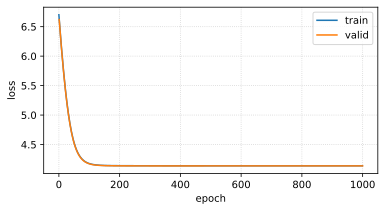

In [21]:
#| code-fold: true
plt.figure(figsize=(6, 3))
plt.plot(history["train"], label="train")
plt.plot(history["valid_steps"], history["valid"], label="valid")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()
plt.grid(linestyle="dotted", alpha=0.6)

The model recovers the latent LF parameters better when coverage is high. Low-coverage LFs have fewer observed (non-abstain) outputs, making their confusion matrices harder to estimate:

In [22]:
from sklearn.metrics import f1_score

def estimated_f1(gen_model, j, p_classes):
    cm = gen_model.C[:, :, j].numpy()
    c = cm[:, :-1] * p_classes.reshape(-1, 1)
    precision = c[1, 1] / c[:, 1].sum()
    recall = c[1, 1] / c[1, :].sum()
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def estimated_cov(gen_model, j, p_classes):
    cm = gen_model.C[:, :, j].numpy()
    learned_cov = cm[:, -1]
    return (1 - (learned_cov * p_classes).sum()).item()

rows = []
p_classes = np.array(list(LABEL_PROBS.values()))
for j in range(len(lf_params)):
    est_cov = estimated_cov(gen_model, j, p_classes)
    est_f1 = estimated_f1(gen_model, j, p_classes)
    mask = L_train[:, j] != ABSTAIN
    emp_f1 = f1_score(L_train[mask, j], y_train[mask]) # empirical F1

    rows.append({
        "lf":         f"LF{j+1}",
        "latent cov": lf_params[j][0],
        "est cov":    round(est_cov, 2),
        "latent F1":  round(emp_f1, 2),
        "est F1":     round(est_f1, 2),
    })
    
pd.DataFrame(rows).set_index("lf")

,latent cov,est cov,latent F1,est F1
lf,,,,
LF1,0.30,0.30,0.78,0.80
LF2,0.50,0.49,0.69,0.68
LF3,0.40,0.40,0.74,0.74
LF4,0.20,0.20,0.82,0.80
LF5,0.25,0.25,0.92,0.88


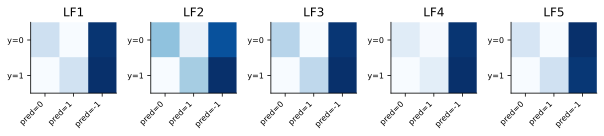

In [23]:
#| code-fold: true
from notebooks.plot import Plot

# Create a plot
p = Plot(1, len(labeling_funcs), figsize=(8.5, 2))

for j in range(len(labeling_funcs)):
    p[j].heatmap(
        torch.softmax(gen_model.C[:, :, j], dim=1),
        row_labels=["y=0", "y=1"],
        col_labels=["pred=0", "pred=1", "pred=-1"],
        cmap="Blues",
        fmt=".2f",
        colorbar=False
    )
    p[j].labels(title=f"LF{j + 1}")
p.show()

In [24]:
#| code-fold: true
frames = []
for j in range(len(lf_params)):
    C_j = gen_model.C[:, :, j]
    df = pd.DataFrame(
        C_j.numpy(),
        index=pd.MultiIndex.from_tuples([(f"LF{j+1}", f"y={k}") for k in range(K)]),
        columns=[f"pred={k}" for k in range(K)] + ["abstain"]
    )
    frames.append(df)
pd.concat(frames)

pred=0    pred=1   abstain
LF1 y=0  0.236913  0.066087  0.697000
    y=1  0.066720  0.224577  0.708703
LF2 y=0  0.325948  0.190604  0.483448
    y=1  0.166345  0.307251  0.526405
LF3 y=0  0.286733  0.117105  0.596161
    y=1  0.117708  0.275035  0.607257
LF4 y=0  0.162263  0.049434  0.788304
    y=1  0.043835  0.152780  0.803385
LF5 y=0  0.201383  0.039933  0.758684
    y=1  0.035036  0.225498  0.739466

The trained model can be used to estimate conditional probabilities of targets given LF outputs:

In [25]:
# Simple test that the model learned (without using latent labels):
l = torch.tensor([[1, 1, 1, 1, 1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_pos): {gen_model.predict_proba(l)[0, y].item():.4f}")

print()
l = torch.tensor([[0, 0, 0, 0, 0]])
for y in range(K):
    print(f"p(y={y} | Λ=all_neg): {gen_model.predict_proba(l)[0, y].item():.4f}")

p(y=0 | Λ=all_pos): 0.0030
p(y=1 | Λ=all_pos): 0.9970

p(y=0 | Λ=all_neg): 0.9959
p(y=1 | Λ=all_neg): 0.0041


The conditional probabilities of targets given LF outputs sum to 1 (passes sanity check).

In [26]:
l = torch.tensor([[-1, -1, -1, -1, -1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_abstain): {gen_model.predict_proba(l)[0, y].item():.4f}")

p(y=0 | Λ=all_abstain): 0.3731
p(y=1 | Λ=all_abstain): 0.6269


:::{.callout-note}
When all LFs abstain, the posterior is:

$$p(y \mid \text{all abstain}) = \frac{p_y \cdot \prod_j C^j_{y,\,K}}{\sum_{y'} p_{y'} \cdot \prod_j C^j_{y',\,K}}$$

This only equals the prior $p_y$ if $\prod_j C^j_{y,K}$ is the same for all $y$ — i.e., the joint abstention rate is class-independent. In general it's **not** exactly the prior; the abstain column of each confusion matrix can differ across rows, so even "all abstain" carries some signal about $y$.

That said, in practice abstention rates are often similar across classes (an LF fires on surface patterns, not the true label directly), so the posterior approximately collapses to the prior. And conceptually this makes sense: if no LF speaks up, the best you can do is fall back on your base rate.
:::

### Label inference (binary)

Soft labels can be generated for a test input using $p_{\hat{\Phi}}(y \mid \lambda_\textbf{\textsf{x}})$ calculated using learned LF parameters. This already takes into account the prior label distribution. In particular, if all LFs abstain, then the model falls back roughly to the prior label distribution (see above note). Evaluating by means of ground truth labels:

In [27]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

def evaluate(model, x, y, t=0.5, verbose=True):
    m = x.shape[0]
    preds = model.predict(x, t)
    f1 = f1_score(y.numpy(), preds.numpy(), average="weighted")
    recall = recall_score(y.numpy(), preds.numpy(), average="weighted")
    precision = precision_score(y.numpy(), preds.numpy(), average="weighted")
    
    if verbose:
        print(confusion_matrix(y.numpy(), preds.numpy()))
    
    return {
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "m": m, "message": f"m={m}, f1={f1:.5f}, t={t:.5f}"
    }

# Since data is imbalanced t=0.5 can be suboptimal (assuming calibrated probs)
t_cal = torch.quantile(gen_model.predict_proba(L_train)[:, 1], q=LABEL_PROBS[0])
print(evaluate(gen_model, L_train, y_train, t=t_cal)["message"]); print()
print(evaluate(gen_model, L_valid, y_valid, t=t_cal)["message"])

[[2220 1023]
 [ 946 3811]]
m=8000, f1=0.75338, t=0.62691

[[554 232]
 [220 994]]
m=2000, f1=0.77369, t=0.62691


:::{.callout-tip}
**Matching the label prior distribution.** The threshold for predicting hard labels can be calibrated by using the prior label distribution. Let $\pi = p_1.$ We want:
$\textrm{P}(f(x) \geq t)=\pi$ which implies 
$\textrm{P}(f(x)<t)=1-\pi.$ This is exactly what a $q$-quantile gives: the value below which fraction $q$ of data lies. So:

$$
t= \text{ quantile at } (1-\pi).
$$ 

This can be helpful as a label-free technique to tune decision threshold esp. for imbalanced class distribution.
:::

`GenModel` integrates all five LFs and still reaches F1 ~0.78 on the synthetic validation set, which is consistent with the F1 of the LFs weighted by coverage[^lf_f1]. This is expected: rather than being bounded by the best LF, the model pools signal from all LFs. When the LFs make *conditionally independent errors*, agreement between them raises confidence and the **ensemble** can potentially push F1 above what any single LF achieves alone.

[^lf_f1]: Recall that the five simulated LFs have F1 ranging from 0.66 to 0.90, with coverages of 20–50%. In particular, LF5 has the highest F1 at 0.92, but fires on only 25% of examples. 

In [28]:
# F1 weighted by coverage
df = pd.DataFrame(rows).set_index("lf")
((df["est cov"] * df["est F1"]).sum() / df["est cov"].sum()).item()

0.7617073170731707

:::{.callout-note}
For evaluation, we will focus on F1 score for interpretability. But we can also just look at validation loss (e.g. for the multi-class setting).
:::

### Noise-aware training

Noise-aware training amounts to weighting the loss with the estimate of the generative model for each target ${p_{\hat{\Phi}}(y \mid \lambda_\textbf{\textsf{x}})} = {p_{\hat{\Phi}}(y,\, \lambda_\textbf{\textsf{x}})}
\, /\, {p_{\hat{\Phi}}(\lambda_\textbf{\textsf{x}})}.$ This allows us to train a model without labels:

In [29]:
import torch.nn as nn
import torch.nn.functional as F
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


class Predictor:
    def __init__(self, clf, num_classes):
        self.K = num_classes
        self.clf = clf

    @torch.no_grad()
    def predict_proba(self, x):
        """Return class probabilities. Shape: (m, K)."""
        logits = self.clf(x)                                       # (m, K)
        return torch.softmax(logits, dim=1)

    @torch.no_grad()
    def predict(self, x, t=None):
        """Predict labels. For binary, threshold t on p(y=1) can be used."""
        probs = self.predict_proba(x)
        if t is not None and self.K == 2:
            return (probs[:, 1] >= t).long()
        return probs.argmax(dim=1)


class NoiseAwareTrainer(Predictor):
    def __init__(self, clf, gen_model):
        self.clf = clf
        self.K = gen_model.K
        self.gen_model = gen_model

    def loss_fn(self, L, x):
        with torch.no_grad():
            # p(y | Λ) for each class — shape (m, K)
            cond_probs = self.gen_model.predict_proba(L)
        logits = self.clf(x)                                       # (m, K)
        log_probs = torch.log_softmax(logits, dim=1)               # (m, K)
        return -(cond_probs * log_probs).sum(dim=1).mean()          # <1>

    def run(self, x_train, L_train, x_valid, y_valid, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1, optimizer="sgd"):
        m = x_train.shape[0]
        history = {"train": [], "valid": [], "valid_steps": []}
        best_loss = np.inf
        best_train_loss = np.inf
        best_epoch = 0
        if optimizer == "adam":
            optim = torch.optim.Adam(self.clf.parameters(), lr=lr, weight_decay=alpha)
        else:
            optim = torch.optim.SGD(self.clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)
        
        tmp = NamedTemporaryFile(suffix=".pt", delete=True)

        try: 
            for epoch in tqdm(range(epochs)):
                B = torch.randperm(m)
                epoch_train_losses = []
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]
                    loss = self.loss_fn(L_train[batch], x_train[batch])

                    # gradient step
                    loss.backward()
                    optim.step()
                    optim.zero_grad()

                    # callbacks
                    epoch_train_losses.append(loss.item())
                    history["train"].append(loss.item())
                            
                    del loss
                    torch.cuda.empty_cache()
                
                with torch.no_grad():
                    if x_valid is not None:
                        val_loss = F.cross_entropy(self.clf(x_valid), y_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((epoch + 1) * (m // bs))
                        if val_loss < best_loss:
                            best_loss = val_loss.item()
                            best_train_loss = np.mean(epoch_train_losses)
                            best_epoch = epoch
                            torch.save(self.clf.state_dict(), tmp.name)

                if epoch - best_epoch > int(0.05 * epochs):
                    print(f"Early stopping at epoch {epoch}...")
                    raise KeyboardInterrupt

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            print(f"Best train loss: {best_train_loss:.4f} | Best valid loss: {best_loss:.4f}")
            self.clf.load_state_dict(torch.load(tmp.name, weights_only=True))
            return history


clf = nn.Sequential(nn.Linear(2, 8), nn.SELU(), nn.Linear(8, K))
trainer = NoiseAwareTrainer(clf, gen_model)
history = trainer.run(x_train, L_train, x_valid, y_valid, epochs=120, bs=32, lr=0.003, alpha=0.0, momentum=0.1)

100%|██████████| 120/120 [00:06<00:00, 18.04it/s]

Best train loss: 0.6671 | Best valid loss: 0.6511


1. A shorthand for this is: `F.cross_entropy(logits, cond_probs)`.

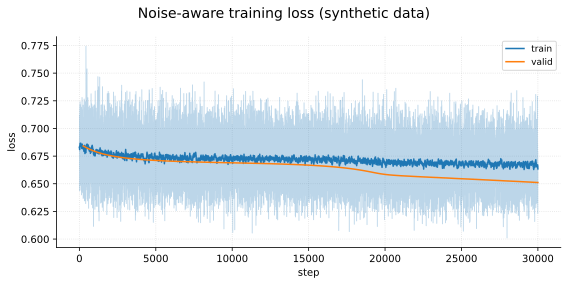

In [30]:
#| code-fold: true
from notebooks.plot import Plot

def plot_history(history, title=""):
    p = Plot(figsize=(8, 4), title=title)
    p[0].line(history["train"], color="C0", label="train", smooth=100)
    p[0].line(history["valid"], x=history["valid_steps"], color="C1", label="valid")
    p[0].labels(x="step", y="loss")
    p.legend(loc="upper right", frameon=True)
    p.show()

plot_history(history, title="Noise-aware training loss (synthetic data)")

The model is not calibrated at the default decision threshold (`0.5`) due to imbalance:

In [31]:
t_cal = torch.quantile(trainer.predict_proba(x_train)[:, 1], q=LABEL_PROBS[0])
print(evaluate(trainer, x_train, y_train, t=t_cal)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_cal)["message"])

[[2321  922]
 [ 879 3878]]
m=8000, f1=0.77463, t=0.59137

[[ 533  253]
 [ 195 1019]]
m=2000, f1=0.77432, t=0.59137


**NOTE:** Not much better than `GenModel`. The next sections uses more a realistic dataset.

## IMDB Movie Reviews

We apply the same weak supervision pipeline to a real text classification task: **IMDB movie review sentiment analysis**. The key challenge is adapting our `GenModel` and `NoiseAwareTrainer` (designed for tensor inputs) to work with raw text data. We define text-based labeling functions that detect sentiment patterns, wrap them to be tensor-compatible, and use TF-IDF features to train the noise-aware discriminative model.

In [32]:
#| output: false
import re
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Load IMDB dataset (16000 train in total, 1000 valid + 2000 oracle)
ds = load_dataset("imdb")
datasets = {
    "test": ds["test"].shuffle(seed=RANDOM_SEED),
    "train": ds["train"].shuffle(seed=RANDOM_SEED),
}

load_subset = lambda split, n: datasets[split].select(range(*n))
ds_train  = load_subset("train", (0, 16000))
ds_valid  = load_subset("test", (0, 1000))
ds_oracle = load_subset("test", (1000, 3000))

train_texts  = ds_train["text"]
valid_texts  = ds_valid["text"]
oracle_texts = ds_oracle["text"]

train_labels  = torch.tensor(ds_train["label"])   # {0, 1}
valid_labels  = torch.tensor(ds_valid["label"])
oracle_labels = torch.tensor(ds_oracle["label"])

# Slices for training, validation, and oracle sets
y_train, y_valid, y_oracle = {}, {}, {}
x_train, x_valid, x_oracle = {}, {}, {}
L_train, L_valid, L_oracle = {}, {}, {}

# Labeled budget: 400 validation | 200 fine-tuning (disjoint)
y_valid["i=0:400"]   = valid_labels[:400]
y_train["i=0:3000"]  = train_labels[:3000]
y_oracle["i=0:2000"] = oracle_labels[:2000]

K = 2
ABSTAIN = -1

:::{.callout-tip}
The convention for the datasets is that `train`, `valid`, and `oracle` are all disjoint corpuses of text and corresponding ground truth labels. Then, we just index on these sets to get specific splits for our experiments. In particular, `train` has 16,000 data points but we only use a slice of size 3,000 to train the first model, and so on.
:::

:::{.callout-note}
In what follows, all training samples are unlabeled. But we reserve a small budget of 400 *labeled* examples for **early stopping** and **evaluation**. Having ground truth is unavoidable. Otherwise, we will make design decisions based on noisy estimates. We will expect that the evals are optimistic since we're early stopping on the same eval set.
:::

### Labeling functions

In [33]:

# (1) Strong adjectives
def lf_strong_sentiment(text):
    text = text.lower()
    pos_words = ["excellent", "masterpiece", "outstanding", "brilliant", "perfect", "superb", "fantastic", "wonderful"]
    neg_words = ["terrible", "awful", "horrible", "worst", "dreadful", "atrocious", "abysmal", "pathetic"]
    pos = any(w in text for w in pos_words)
    neg = any(w in text for w in neg_words)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (2) Balance of positive/negative word counts
def lf_sentiment_words(text):
    text = text.lower()
    pos_words = ["great", "love", "amazing", "best", "enjoyed", "favorite", "fun"]
    neg_words = ["bad", "waste", "boring", "poor", "stupid", "annoying", "disappointing"]
    pos_count = sum(1 for w in pos_words if w in text)
    neg_count = sum(1 for w in neg_words if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (3) Explicit ratings (e.g. "10/10", "1 star")
def lf_rating_mention(text):
    text = text.lower()
    pos_patterns = [r"10/10", r"10 out of 10", r"5 stars", r"5/5"]
    neg_patterns = [r"1/10", r"1 out of 10", r"1 star[^s]", r"0 stars", r"0/10"]
    pos = any(re.search(p, text) for p in pos_patterns)
    neg = any(re.search(p, text) for p in neg_patterns)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (4) Re-watch / walk-out behavior
def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "seen it multiple times", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish", "wasted 2 hours"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (5) Negative comparative phrases
def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower or "disappointing compared" in text_lower:
        return 0
    return ABSTAIN


# (6) Recommendation / avoidance phrases
def lf_recommendation(text):
    text = text.lower()
    pos_phrases = ["highly recommend", "must see", "must watch", "worth watching", "go see", "definitely watch", "check it out"]
    neg_phrases = ["do not recommend", "don't recommend", "avoid", "skip this", "don't bother", "don't waste", "stay away", "save your"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (7) Exclamation + sentiment phrases
def lf_exclamation_sentiment(text):
    if "!" not in text: return ABSTAIN
    text = text.lower()
    pos_phrases = ["loved it", "great film", "great movie", "must see", "highly recommended", "well done"]
    neg_phrases = ["waste of time", "don't watch", "stay away", "save your money", "never again", "so bad"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN



# (8) Negation + positive word (likely negative review)
def lf_negated_positive(text):
    text = text.lower()
    patterns = ["not good", "not great", "not worth", "wasn't good", "wasn't great",
                "isn't good", "isn't great", "not funny", "not entertaining"]
    if any(p in text for p in patterns):
        return 0
    return ABSTAIN


# (9) Profanity / strong negative language
def lf_profanity(text):
    text = text.lower()
    words = ["crap", "crapfest", "crap fest", "crap-fest", "sucks", "crapfest"]
    if any(w in text for w in words):
        return 0
    return ABSTAIN


# (10) Emotional positive language
def lf_emotional_positive(text):
    text = text.lower()
    phrases = ["moved me", "brought me to tears", "touched my heart", "blew me away",
               "left me speechless", "changed my life", "emotional rollercoaster"]
    if any(p in text for p in phrases):
        return 1
    return ABSTAIN


# (11) Length heuristic: very short reviews tend negative
def lf_short_review(text):
    if len(text.split()) < 30:
        return 0
    return ABSTAIN


# (12) All-caps words (strong emotion, check sentiment)
def lf_allcaps_sentiment(text):
    caps_words = [w for w in text.split() if w.isupper() and len(w) > 2]
    if len(caps_words) < 2:
        return ABSTAIN
    pos = ["GREAT", "LOVE", "AMAZING", "BEST", "PERFECT", "AWESOME", "WONDERFUL"]
    neg = ["WORST", "TERRIBLE", "AWFUL", "HORRIBLE", "BAD", "HATE", "BORING"]
    pos_count = sum(1 for w in caps_words if w in pos)
    neg_count = sum(1 for w in caps_words if w in neg)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (13) Director/actor praise
def lf_actor_praise(text):
    text = text.lower()
    pos = ["brilliant performance", "brilliant acting", "great performance",
           "great acting", "superb acting", "amazing performance", "stellar cast"]
    neg = ["terrible acting", "awful performance", "wooden acting",
           "bad acting", "can't act", "overacting", "miscast"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (14) Plot quality
def lf_plot_quality(text):
    text = text.lower()
    pos = ["great plot", "compelling story", "well-written", "clever plot",
           "gripping", "riveting", "page-turner", "engaging story"]
    neg = ["no plot", "plot holes", "predictable", "makes no sense",
           "incoherent", "nonsensical", "poorly written", "lazy writing"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (15) Ending sentiment
def lf_ending(text):
    text = text.lower()
    pos = ["great ending", "perfect ending", "satisfying ending", "loved the ending"]
    neg = ["terrible ending", "awful ending", "disappointing ending", "ruined the ending",
           "worst ending", "anticlimactic"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (16) Humor detection
def lf_humor(text):
    text = text.lower()
    pos = ["hilarious", "laugh out loud", "genuinely funny", "had me laughing",
           "comedy gold", "witty"]
    neg = ["not funny", "unfunny", "tries too hard", "forced humor",
           "cringe", "painfully unfunny"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (17) Repetition of negative sentiment words (>= 3 distinct)
def lf_neg_pile(text):
    text = text.lower()
    neg_words = ["bad", "terrible", "awful", "waste", "boring", "stupid",
                 "horrible", "worst", "poor", "disappointing", "dreadful"]
    count = sum(1 for w in neg_words if w in text)
    if count >= 3: return 0
    return ABSTAIN


# (18) Repetition of positive sentiment words (>= 3 distinct)
def lf_pos_pile(text):
    text = text.lower()
    pos_words = ["great", "excellent", "amazing", "love", "wonderful",
                 "brilliant", "fantastic", "superb", "best", "perfect"]
    count = sum(1 for w in pos_words if w in text)
    if count >= 3: return 1
    return ABSTAIN


# (19) Genre-specific praise (horror, thriller)
def lf_genre_tension(text):
    text = text.lower()
    pos = ["edge of my seat", "spine-tingling", "heart-pounding", "genuinely scary",
           "terrifying", "creepy atmosphere", "suspenseful"]
    neg = ["not scary", "laughable horror", "zero suspense", "predictable thriller"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (20) Sarcasm/irony indicators (negated praise patterns)
def lf_sarcasm(text):
    text = text.lower()
    patterns = ["yeah right", "oh wow", "what a masterpiece", "brilliant...",
                "great job", "sure it was good", "if you like watching paint dry"]
    # These are tricky - only fire on strong sarcasm indicators
    if any(p in text for p in ["if you like watching paint dry", "what a waste"]):
        return 0
    return ABSTAIN


text_lfs = [
    lf_strong_sentiment,       # 0
    lf_sentiment_words,        # 1
    lf_rating_mention,         # 2
    lf_viewing_experience,     # 3
    lf_comparative_sentiment,  # 4
    lf_recommendation,         # 5
    lf_exclamation_sentiment,  # 6
    lf_negated_positive,       # 7
    lf_profanity,              # 8
    lf_emotional_positive,     # 9
    lf_short_review,           # 10
    lf_allcaps_sentiment,      # 11
    lf_actor_praise,           # 12
    lf_plot_quality,           # 13
    lf_ending,                 # 14
    lf_humor,                  # 15
    lf_neg_pile,               # 16
    lf_pos_pile,               # 17
    lf_genre_tension,          # 18
    lf_sarcasm,                # 19
]

Peeking into the latent performance of the LFs:

In [34]:
# Coverage, accuracy, and F1 on train set
stats = []
for lf in text_lfs:
    outputs = [lf(t) for t in train_texts]
    labels = train_labels.numpy()
    fired = [i for i, o in enumerate(outputs) if o != ABSTAIN]
    cov = len(fired) / len(outputs)
    actual_f1 = f1_score([labels[i] for i in fired], [outputs[i] for i in fired], average="weighted") if fired else 0.0

    valid_outputs = [lf(t) for t in valid_texts[:400]]
    valid_fired = [i for i, o in enumerate(valid_outputs) if o != ABSTAIN]
    valid_cov = len(valid_fired) / len(valid_outputs)
    valid_f1 = f1_score([y_valid["i=0:400"][i] for i in valid_fired], [valid_outputs[i] for i in valid_fired], average="weighted") if valid_fired else 0.0
    
    stats.append({
        "LF": lf.__name__,
        "cov": f"{cov:.3f}",
        "cov (valid)": f"{valid_cov:.3f}",
        "F1": f"{actual_f1:.3f}",
        "F1 (valid)": f"{valid_f1:.3f}",
    })

pd.DataFrame(stats)

,LF,cov,cov (valid),F1,F1 (valid)
0,lf_strong_sentiment,0.413,0.425,0.864,0.835
1,lf_sentiment_words,0.698,0.725,0.748,0.725
2,lf_rating_mention,0.023,0.018,0.821,0.851
3,lf_viewing_experience,0.012,0.018,0.855,1.000
4,lf_comparative_sentiment,0.014,0.018,0.674,0.416
5,lf_recommendation,0.121,0.080,0.809,0.875
6,lf_exclamation_sentiment,0.051,0.037,0.850,0.933
7,lf_negated_positive,0.029,0.028,0.718,0.736
8,lf_profanity,0.056,0.058,0.772,0.935
9,lf_emotional_positive,0.003,0.003,0.892,0.000


:::{.callout-tip}
For fun, we see the difference between actual LF quality vs. estimate from the 400 labeled sample that we have. You can imagine that in practice you only see the last two columns. That is, you will have to navigate with imperfect information with the discrepancy becoming larger the noisier your dataset is.
:::

### Model training

**LF outputs & features.** Here we precompute the LF outputs for the raw reviews and stack them into $\Lambda$ matrices, mirroring the above synthetic pipeline. We also extract TF-IDF features as the input representation for the discriminative model:

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_L_text(labeling_funcs, texts):
    """Build LF output matrix from text labeling functions."""
    return torch.tensor([[lf(t) for lf in labeling_funcs] for t in texts])

# LF matrices (independent of feature variant)
L_valid["i=0:400"]    = build_L_text(text_lfs, valid_texts[:400])
L_train["i=0:3000"]   = build_L_text(text_lfs, train_texts[:3000])
L_oracle["i=0:2000"]  = build_L_text(text_lfs, oracle_texts[:2000])

# 5k unigram TF-IDF features on train set (3000 reviews)
vec_5k = TfidfVectorizer(max_features=5000)
vec_5k.fit(train_texts[:3000])

f_vec = lambda vec, texts: torch.tensor(vec.transform(texts).toarray(), dtype=torch.float32)
x_valid["i=0:400,d=5k"]     = f_vec(vec_5k, valid_texts[:400])
x_train["i=0:3000,d=5k"]    = f_vec(vec_5k, train_texts[:3000])
x_oracle["i=0:2000,d=5k"]   = f_vec(vec_5k, oracle_texts[:2000])

**Generative model.** We train `GenModel` on the text LF outputs with a balanced prior. The model learns the latent confusion matrix of each LF and produces soft labels $p_{\hat{\Phi}}(y \mid \lambda_{\textbf{\textsf{x}}_i})$ for every review:

In [36]:
IMDB_LABEL_PROBS = {0: 0.50, 1: 0.50}

# can use L_valid to validate since there's no early stopping leakage
gen_model_imdb = GenModel(num_classes=2, num_lfs=len(text_lfs), class_prior=IMDB_LABEL_PROBS)
history_gen_imdb = gen_model_imdb.fit(L_train["i=0:3000"], L_valid["i=0:400"], epochs=1000, lr=0.03)

100%|██████████| 1000/1000 [00:01<00:00, 688.12it/s]


Training and validation NLL for the generative model:

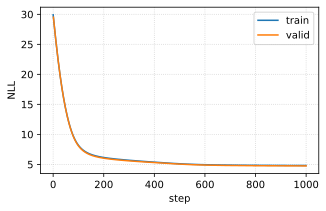

In [37]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_gen_imdb["train"], label="train")
plt.plot(history_gen_imdb["valid_steps"], history_gen_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(linestyle="dotted", alpha=0.6);

**Noise-aware training.** We train an MLP on TF-IDF features using the noise-aware loss, weighted by the generative model's soft labels. The discriminative model can generalize beyond the keywords used in the LFs by leveraging the full TF-IDF vocabulary:

In [38]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_imdb = nn.Sequential(
    nn.Linear(5000, 32), 
    nn.SELU(), 
    nn.Linear(32, K)
)

trainer_imdb = NoiseAwareTrainer(clf_imdb, gen_model_imdb)
history_nat_imdb = trainer_imdb.run(
    x_train["i=0:3000,d=5k"], L_train["i=0:3000"], x_valid["i=0:400,d=5k"], y_valid["i=0:400"],
    epochs=300, bs=64, lr=0.003, alpha=0.0, momentum=0.9,
)

 49%|████▉     | 147/300 [00:05<00:05, 26.56it/s]

Early stopping at epoch 147...
Training stopped.
Best train loss: 0.3815 | Best valid loss: 0.4036


Training and validation loss for the noise-aware discriminative model:

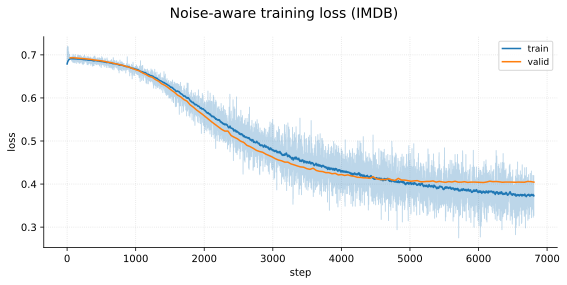

In [39]:
plot_history(history_nat_imdb, title="Noise-aware training loss (IMDB)")

### Evaluation

In [40]:
print("GenModel (IMDB):")
print(evaluate(gen_model_imdb, L_train["i=0:3000"], y_train["i=0:3000"])["message"]); print()
print(evaluate(gen_model_imdb, L_valid["i=0:400"],  y_valid["i=0:400"])["message"])

print("\nNoiseAwareTrainer (IMDB):")
print(evaluate(trainer_imdb, x_train["i=0:3000,d=5k"], y_train["i=0:3000"])["message"]); print()
print(evaluate(trainer_imdb, x_valid["i=0:400,d=5k"],  y_valid["i=0:400"])["message"])

GenModel (IMDB):
[[1204  304]
 [ 354 1138]]
m=3000, f1=0.78059, t=0.50000

[[157  41]
 [ 55 147]]
m=400, f1=0.75979, t=0.50000

NoiseAwareTrainer (IMDB):
[[1182  326]
 [ 227 1265]]
m=3000, f1=0.81550, t=0.50000

[[159  39]
 [ 36 166]]
m=400, f1=0.81248, t=0.50000


Unlike in the toy dataset, the NAT model outperforms `GenModel` on IMDB reviews. While the generative model can only make predictions from "finite" LF output patterns, the discriminative model leverages [TF-IDF feature vectors]{.mark} to capture sentiment signals beyond the heuristics hardcoded in the LFs. This turns out to matter for a real dataset.

## Self-training on pseudo-labels

Recall that we have the following pipeline for the **generative model** $G$: 

$${\textbf{\textsf{x}}} \underset{\Lambda}{\mapsto} \lambda_{\textbf{\textsf{x}}} \underset{G}{\mapsto} p(\cdot \mid \lambda_\textsf{x}) \in [0, 1]^K.$$

This is what we use to supervise the **NAT model** $f_{\text{NAT}}.$ However, once training is done, the resulting model operates on the inputs without requiring information from the LFs. This is the core advantage of the NAT model: it modulates on complex *learned* features and representations which can assign [confident predictions]{.underline} on examples where labeling functions [abstain]{.underline} or [disagree]{.underline} on — precisely the data points where the generative model's signal is weakest. 

**Model.** [The student shares the NAT architecture but is trained from scratch]{.mark}. Warm-starting from the NAT weights hurt performance in our experiments. One possible explanation is that the pseudo-label loss provides useful gradient signal precisely when the posterior estimates are noisy, and random initialization gives the optimizer more freedom to find a better basin; starting from NAT weights may bias the search toward a region that is well-calibrated for the NAT loss but suboptimal for the augmented objective.

**Training.** We construct the augmented training set by defining two labeled datasets and taking their union:

$$
\begin{aligned}
\mathcal{D}_{\text{gen}} &= \bigl\{\bigl(\textbf{\textsf{x}}_i,\, \tilde{\textbf{\textsf{p}}}_i = p_{\hat{\Phi}}(y \mid \lambda_{\textbf{\textsf{x}}_i})\bigr)\bigr\}_{i=1}^{M}, \\
\mathcal{D}_{\text{pseudo}} &= \bigl\{\bigl(\textbf{\textsf{x}}_i,\, \tilde{\textbf{\textsf{p}}}_i = \text{Softmax}(f_{\text{NAT}}(\textbf{\textsf{x}}_i))\bigr) : \textbf{\textsf{x}}_i \in \mathcal{U},\, w_i \geq \tau_{\text{conf}}\bigr\},
\end{aligned}
$$

where $\mathcal{U}$ is the unlabeled pool, $w_i = \max_k\, \tilde{p}_{ik}$ is the NAT teacher's confidence, and $\tau_{\text{conf}}$ is a threshold (0.85 in our experiments). 
The second coordinate in each pair is a soft label $\tilde{\textbf{\textsf{p}}}_i \in \Delta^{K-1}$ — a probability vector over the $K$ classes rather than a hard one-hot label, where $\Delta^{K-1} = \{\textbf{\textsf{q}} \in \mathbb{R}^K : q_k \ge 0,\, \sum_k q_k = 1\}$ is the $(K{-}1)$-dimensional probability simplex. The student is trained on $\mathcal{D} = \mathcal{D}_{\text{gen}} \cup \mathcal{D}_{\text{pseudo}}$ 
with confidence-weighted soft cross-entropy, where each example is weighted by its confidence $w_i = \max_k\, \tilde{p}_{ik}$:

$$
\begin{aligned}
\mathcal{L}_{\text{Student}}(\Theta) &= -\frac{1}{B} \sum_{i \in \mathcal{B}} w_i \sum_{k=0}^{K-1} \tilde{p}_{ik}\, \log \hat{p}_{\Theta,ik} \\
&= -\frac{1}{B_{\text{gen}} + B_{\text{pseudo}}} \sum_{i \in \mathcal{B}_{\text{gen}}} w_i \sum_{y=0}^{K-1} {p_{\hat{\Phi}}(y \mid \lambda_{\textbf{\textsf{x}}_i})} \, \log \hat{p}_{\Theta,iy} \\
&+ -\frac{1}{B_{\text{gen}} + B_{\text{pseudo}}} \sum_{i \in \mathcal{B}_{\text{pseudo}}} w_i \sum_{k=0}^{K-1} \tilde{p}_{ik}^{\text{NAT}} \, \log \hat{p}_{\Theta,ik},
\end{aligned}
$$

where $\hat{\textbf{\textsf{p}}}_{\Theta,i} = \text{Softmax}(f_\Theta(\textbf{\textsf{x}}_i))$ is the student's predicted distribution and $\mathcal{B} = \mathcal{B}_{\text{gen}} \cup \mathcal{B}_{\text{pseudo}}$ is a mini-batch drawn from $\mathcal{D}$. 

:::{.callout-tip}
$\mathcal{L}_{\text{student}}$ is the original NAT loss augmented with the pseudo-label loss on the unlabeled pool $\mathcal{U}.$
:::

:::{.callout-note}
**On soft labels.** We initially tried hard pseudo-labels via argmax. But this didn't turn out to be consistent over upstream hyperparameter choices (e.g. its too sensitive to the `GenModel`). This makes sense since labels via argmax are lossy: small shifts in the generative model's convergence can flip labels near the decision boundary, cascading errors into the student. (1) Soft targets preserve the label model's uncertainty, and (2) confidence weighting ensures that examples where the generative model or NAT teacher is unsure contribute proportionally less to the gradient. This makes the pipeline more robust to hyperparameter choices upstream.
:::

**Why use the generative model posterior along with $\mathcal{D}_{\text{pseudo}}$?** In NAT training, the generative model posterior steers the loss because the true label is unknown and the model has no prior knowledge of $\textbf{\textsf{x}}$ — every candidate label must contribute, weighted by LF-derived confidence. But by self-training time, the NAT teacher has learned a feature-based mapping: its confident outputs *already encode* the relationship between $\textbf{\textsf{x}}$ and $y$, making them strictly more informative than the generative model's feature-blind posterior. We use these as $\mathcal{D}_{\text{pseudo}}$. 

However, the NAT teacher is only confident on a filtered subset of the pool ($w_i \geq \tau_{\text{conf}}$), so coverage is incomplete. $\mathcal{D}_{\text{gen}}$ fills this gap: on the original training set where LFs fire, the confidence weighted generative model posterior is still the best available signal and anchors the student on the LF-covered region. During SGD, mini-batches are drawn from $\mathcal{D} = \mathcal{D}_{\text{gen}} \cup \mathcal{D}_{\text{pseudo}}$, so the mixing ratio ($|\mathcal{D}_{\text{gen}}| : |\mathcal{D}_{\text{pseudo}}|$ $\approx$ 3:2 in our experiments) controls how much each supervision signal contributes to the gradient on average.

### Teacher model

Since this requires a stronger teacher model, we expand the NAT training set from 3000 to 6000 reviews and switch to bigram TF-IDF (`ngram_range=(1, 2)`, 7000 features), which captures multi-word phrases like "waste of time" or "must watch" that unigram TF-IDF misses. The original generative model (trained on 3000 reviews) is reused to produce soft labels for all 6000 points[^gen_model_retraining]. We keep the [same validation set]{.mark} throughout to ensure comparisons are valid. 

[^gen_model_retraining]: Retraining `GenModel` on the larger set actually hurts performance, our guess is that the additional data dilutes the LF statistics the model was optimized on (we have too few parameters for 6000 data points).

In [41]:
#| output: false
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# Larger training set: 6000 reviews
y_train["i=0:6000"] = train_labels[:6000]
L_train["i=0:6000"] = build_L_text(text_lfs, train_texts[:6000])

# Reuse the original generative model — retraining on 6k hurts performance
# Bigram TF-IDF with 7k features w/ sublinear scaling of TF: i.e. 1 + log(TF)
vec_7k = TfidfVectorizer(max_features=7000, ngram_range=(1, 2), sublinear_tf=True)
vec_7k.fit(train_texts[:6000])

x_valid["i=0:400,d=7k"]     = f_vec(vec_7k, valid_texts[:400])
x_train["i=0:6000,d=7k"]    = f_vec(vec_7k, train_texts[:6000])
x_oracle["i=0:2000,d=7k"]   = f_vec(vec_7k, oracle_texts[:2000])

**Model.** The baseline MLP uses a single hidden layer of 32 units which bottlenecks the 5000 input features. We widen the teacher to two hidden layers (128 and 32 units) and add L2 regularization (`weight_decay=1e-4`) to prevent overfitting on noisy soft labels:

In [42]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_v2 = nn.Sequential(
    nn.Linear(7000, 128), nn.SELU(),
    nn.Linear(128, 32), nn.SELU(),
    nn.Linear(32, K),
)

trainer_v2 = NoiseAwareTrainer(clf_v2, gen_model_imdb)  # <1>
history_v2 = trainer_v2.run(
    x_train["i=0:6000,d=7k"], L_train["i=0:6000"], 
    x_valid["i=0:400,d=7k"], y_valid["i=0:400"],
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9,
)

print()
print("NAT v2 (IMDB, valid):")
print(evaluate(trainer_v2, x_valid["i=0:400,d=7k"], y_valid["i=0:400"])["message"])

 13%|█▎        | 38/300 [00:10<01:10,  3.73it/s]

Early stopping at epoch 38...
Training stopped.
Best train loss: 0.4104 | Best valid loss: 0.3960

NAT v2 (IMDB, valid):
[[160  38]
 [ 29 173]]
m=400, f1=0.83238, t=0.50000


1. The original generative model (trained on 3k) is reused as-is. Its confusion matrices already capture the LF statistics well; applying them to the 6k training set requires only forward inference.

:::{.callout-note}
NAT v2 achieves F1 = 0.8324 — a +2.0pp improvement over the baseline (0.8125). The richer features and more data significantly improved performance. Further payoff comes in the next step. For instance, NAT v2 produces more pseudo-labeled examples than the baseline NAT at higher oracle accuracy.
:::

**Pseudo-labeling.** We apply NAT v2 to 10,000 held-out reviews (indices 6000–16000, disjoint from training and validation) and retain predictions with $\max_y\, p(y \mid \textbf{\textsf{x}}) \geq 0.85$ as pseudo-labels. We also record oracle accuracy — the fraction of pseudo-labels that match the true IMDB labels — as a proxy for pseudo-label quality:

In [43]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# Unlabeled pool: 10k reviews disjoint from train/valid
y_train["i=6000:16000"]         = train_labels[6000:16000]
x_train["i=6000:16000,d=7k"]    = f_vec(vec_7k, train_texts[6000:16000])
y_pool = y_train["i=6000:16000"]
x_pool = x_train["i=6000:16000,d=7k"]

# Get confident pseudo-labels
p_pool = trainer_v2.predict_proba(x_pool)  # (10000, 2)
conf, pseudo_labels = p_pool.max(dim=1)

CONF_THRESHOLD = 0.85
conf_mask = conf >= CONF_THRESHOLD
n_conf = conf_mask.sum().item()
pseudo_acc = (pseudo_labels[conf_mask] == y_pool[conf_mask]).float().mean()

print(f"Confident predictions: {n_conf}/{len(conf_mask)} ({n_conf/len(conf_mask):.1%})")
print(f"Pseudo-label accuracy (oracle check): {pseudo_acc:.3f}")

Confident predictions: 3622/10000 (36.2%)
Pseudo-label accuracy (oracle check): 0.977


NAT v2 labels **36.2%** of the pool at 97.7% oracle accuracy. As an exercise, you can show that the baseline NAT labels 35.6% at 96.4% accuracy. The stronger teacher produces ~60 more pseudo-labeled examples at a slightly higher per-sample accuracy.

In [44]:
#| include: false
# Exercise: baseline NAT pseudo-label coverage and oracle accuracy
x_pool_v1 = f_vec(vec_5k, train_texts[6000:16000])
p_pool_v1 = trainer_imdb.predict_proba(x_pool_v1)
confidence_v1, pseudo_labels_v1 = p_pool_v1.max(dim=1)

mask_v1 = confidence_v1 >= CONF_THRESHOLD
n_confident_v1 = mask_v1.sum().item()
pseudo_acc_v1 = (pseudo_labels_v1[mask_v1] == y_pool[mask_v1]).float().mean()
print(n_conf - n_confident_v1)
print(f"Confident predictions: {n_confident_v1}/{len(mask_v1)} ({n_confident_v1/len(mask_v1):.1%})")
print(f"Pseudo-label accuracy (oracle check): {pseudo_acc_v1:.3f}")

64
Confident predictions: 3558/10000 (35.6%)
Pseudo-label accuracy (oracle check): 0.964


### Student model

Combined generative and pseudo-labeled targets to train the student model:

In [45]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Soft labels from generative model for original training set
p_gen = gen_model_imdb.predict_proba(L_train["i=0:6000"])

# Soft pseudo-labels from NAT teacher, filtered by confidence
x_pool = x_train["i=6000:16000,d=7k"]
p_pool = trainer_v2.predict_proba(x_pool)
x_combined = torch.cat([x_train["i=0:6000,d=7k"], x_pool[conf_mask]], dim=0)
t_combined = torch.cat([p_gen, p_pool[conf_mask]], dim=0)

print(f"Combined training set: {x_combined.shape[0]} examples")
print(f"  Soft labels from gen model: {x_train["i=0:6000,d=7k"].shape[0]}")
print(f"  Pseudo-labeled (confident): {conf_mask.sum().item()}")

Combined training set: 9622 examples
  Soft labels from gen model: 6000
  Pseudo-labeled (confident): 3622


The full pipeline is encapsulated in `PseudoLabelSelfTrainer`. Given a generative model and a trained NAT teacher. It (1) obtains **soft probability distributions** from the generative model posterior, (2) scores an unlabeled pool with the teacher and retains confident predictions $w = \max \hat{p} \geq \tau_{\text{conf}}$, and (3) trains on the combined dataset using soft cross-entropy, weighting each example by its confidence $w_i$:

In [46]:
import torch.nn as nn
import torch.nn.functional as F
from tempfile import NamedTemporaryFile

def supervised_training_loop(
    clf, 
    x_train, y_train, 
    x_valid, y_valid,
    weights=None,
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9,
    optimizer="sgd"
):
    """Supervised training with cross-entropy loss and optional per-example weights."""
    m = x_train.shape[0]
    best_loss, best_epoch = np.inf, 0
    best_train_loss = np.inf
    history = {"train": [], "valid": [], "valid_steps": []}
    tmp = NamedTemporaryFile(suffix=".pt", delete=True)
    if optimizer == "adam":
        optim = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=alpha)
    else:
        optim = torch.optim.SGD(clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)

    try:
        for epoch in tqdm(range(epochs)):
            B = torch.randperm(m)
            epoch_train_losses = []
            for i in range(m // bs):
                batch = B[i * bs: (i + 1) * bs]
                loss = F.cross_entropy(clf(x_train[batch]), y_train[batch], reduction="none")
                if weights is not None:
                    loss = loss * weights[batch]
                loss = loss.mean()
                loss.backward()
                optim.step()
                optim.zero_grad()
                epoch_train_losses.append(loss.item())
                history["train"].append(loss.item())

            with torch.no_grad():
                val_loss = F.cross_entropy(clf(x_valid), y_valid)
                history["valid"].append(val_loss.item())
                history["valid_steps"].append((epoch + 1) * (m // bs))
                if val_loss < best_loss:
                    best_loss = val_loss.item()
                    best_train_loss = np.mean(epoch_train_losses)
                    best_epoch = epoch
                    torch.save(clf.state_dict(), tmp.name)

            if epoch - best_epoch > int(0.05 * epochs):
                print(f"Early stopping at epoch {epoch}...")
                raise KeyboardInterrupt

    except KeyboardInterrupt:
        print("Training stopped.")
    finally:
        print(f"Best train loss: {best_train_loss:.4f} | Best valid loss: {best_loss:.4f}")
        clf.load_state_dict(torch.load(tmp.name, weights_only=True))
        return history


class PseudoLabelSelfTrainer(Predictor):
    def __init__(self, clf, gen_model, nat_model, conf_threshold=0.85):
        self.clf = clf
        self.K = gen_model.K
        self.gen_model = gen_model
        self.nat_model = nat_model
        self.conf_threshold = conf_threshold

    def build_pseudo_labels(self, x_pool):
        with torch.inference_mode():
            probs = torch.softmax(self.nat_model(x_pool), dim=1)
        mask = probs.max(dim=1).values >= self.conf_threshold
        return mask, probs

    def build_gen_labels(self, L):
        return self.gen_model.predict_proba(L)

    def build_train_dataset(self, x_train, x_pool, L_train):
        p_gen = self.build_gen_labels(L_train)                  # (M, K) gen probas
        mask, p_pseudo = self.build_pseudo_labels(x_pool)       # filter + nat probas
        x_combined = torch.cat([x_train, x_pool[mask]], dim=0)
        t_combined = torch.cat([p_gen, p_pseudo[mask]], dim=0)
        weights = t_combined.max(dim=1).values                  # confidence weights
        return x_combined, t_combined, weights

    def run(self, x_train, x_pool, L_train, x_valid, y_valid, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1, optimizer="sgd"):
        x_combined, t_combined, weights = self.build_train_dataset(x_train, x_pool, L_train)
        return supervised_training_loop(
            self.clf, 
            x_combined, t_combined,     # <1>
            x_valid, y_valid,
            weights=weights,
            epochs=epochs, bs=bs, lr=lr, alpha=alpha, momentum=momentum,
            optimizer=optimizer
        )

1. Recall that we can just put probabilities in place of hard labels in `F.cross_entropy` so that we can re-use the same supervised training loop typically used for hard label training by inputing soft targets in the targets argument.

In [47]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_self = nn.Sequential(
    nn.Linear(7000, 128), nn.SELU(),
    nn.Linear(128, 32), nn.SELU(),
    nn.Linear(32, K),
)

self_trainer = PseudoLabelSelfTrainer(clf_self, gen_model_imdb, nat_model=trainer_v2.clf)
self_history = self_trainer.run(
    x_train["i=0:6000,d=7k"], 
    x_pool=x_train["i=6000:16000,d=7k"], 
    L_train=L_train["i=0:6000"],
    x_valid=x_valid["i=0:400,d=7k"], y_valid=y_valid["i=0:400"],
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9
)

  9%|▉         | 28/300 [00:12<02:03,  2.19it/s]

Early stopping at epoch 28...
Training stopped.
Best train loss: 0.2968 | Best valid loss: 0.3861


In [48]:
print("Student model (valid):")
print(evaluate(self_trainer, x_valid["i=0:400,d=7k"], y_valid["i=0:400"])["message"])

Student model (valid):
[[162  36]
 [ 28 174]]
m=400, f1=0.83990, t=0.50000


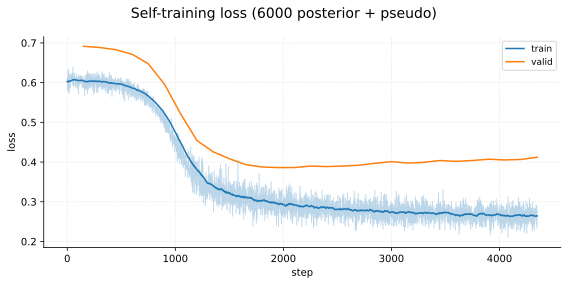

In [49]:
plot_history(self_history, title="Self-training loss (6000 posterior + pseudo)")

**Figure.** Recall that our validation loss is always different from the training loss (starting from NAT). Here the train loss is one magnitude lower which is expected since its scaled by weights $w \in [0, 1].$

In [50]:
#| include: false
# To separate the effect of self-training from the NAT v2 improvements, 
# we repeat the procedure with the original baseline NAT as teacher —
# unigram TF-IDF (5k), 3000 training examples, same [32] architecture —
# on a disjoint pool starting at index 3000. The student also uses unigram 
# features, so only the pseudo-labeling step changes:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_self_abl = nn.Sequential(
    nn.Linear(5000, 32), nn.SELU(),
    nn.Linear(32, K)
)

x_pool_v1 = f_vec(vec_5k, train_texts[6000:16000])
self_trainer_abl = PseudoLabelSelfTrainer(clf_self_abl, gen_model_imdb, nat_model=trainer_imdb.clf)
self_history_abl = self_trainer_abl.run(
    x_train["i=0:3000,d=5k"], x_pool_v1, L_train["i=0:3000"],
    x_valid["i=0:400,d=5k"], y_valid["i=0:400"],
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9
)

print("\nAblation — NAT baseline + pseudo (valid):")
print(evaluate(self_trainer_abl, x_valid["i=0:400,d=5k"], y_valid["i=0:400"])["message"])

 27%|██▋       | 80/300 [00:09<00:25,  8.71it/s]

Early stopping at epoch 80...
Training stopped.
Best train loss: 0.2647 | Best valid loss: 0.3900

Ablation — NAT baseline + pseudo (valid):
[[159  39]
 [ 28 174]]
m=400, f1=0.83233, t=0.50000


## Supervised fine-tuning

We reserve a separate set of 200 labeled examples (disjoint from the 400 used for evaluation) to **fine-tune** the self-trained model. We run a few additional epochs of standard cross-entropy on top of `self_trainer.clf` — the weights are already well-initialized from self-training, so even a small labeled signal can correct residual errors near the decision boundary:

In [51]:
import copy
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_ft = copy.deepcopy(self_trainer.clf)  # <1>

y_valid["i=400:600"] = valid_labels[400:600]
x_valid["i=400:600,d=7k"] = f_vec(vec_7k, valid_texts[400:600])

history_ft = supervised_training_loop(
    clf_ft, 
    x_train=x_valid["i=400:600,d=7k"],  # <2>
    y_train=y_valid["i=400:600"], 
    x_valid=x_valid["i=0:400,d=7k"],
    y_valid=y_valid["i=0:400"],  
    epochs=300, bs=32, lr=0.0003, alpha=1e-5, momentum=0.9    # <3>
)

predictor_ft = Predictor(clf_ft, K)
print("Fine-tuned model (valid):")
print(evaluate(predictor_ft, x_valid["i=0:400,d=7k"], y_valid["i=0:400"], t=0.5)["message"])

 77%|███████▋  | 231/300 [00:04<00:01, 53.57it/s]

Early stopping at epoch 231...
Training stopped.
Best train loss: 0.0580 | Best valid loss: 0.3544
Fine-tuned model (valid):
[[158  40]
 [ 16 186]]
m=400, f1=0.85941, t=0.50000


1. Fine-tuning from `self_trainer.clf` weights rather than random initialization is critical: the model already understands the task, so the 200 labels only need to nudge the decision boundary, not learn representations from scratch.
2. Fine-tune on a separate 200 labeled examples (`x_valid["i=400:600,d=7k"]`), disjoint from the 400 used for validation.
3. Since this is fine-tuning on hard labels, we set a small LR (i.e. 10x smaller compared to NAT / self-training). Since we decreased LR, we decrease *B* from 64 -> 32.

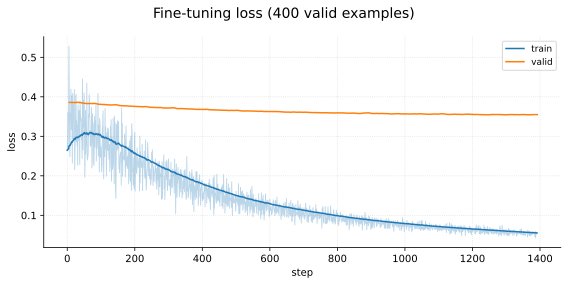

In [52]:
plot_history(history_ft, title="Fine-tuning loss (400 valid examples)")

In [53]:
#| include: false
# **Ablation: supervised from scratch.** To confirm that the fine-tuning 
# gain comes from the weak supervision initialization rather than the 200 
# labels alone, we train the same architecture from random weights using 
# only the 200 labeled examples:

np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_scratch = nn.Sequential(
    nn.Linear(7000, 128),
    nn.SELU(),
    nn.Linear(128, 32),
    nn.SELU(),
    nn.Linear(32, K),
)

history_scratch = supervised_training_loop(
    clf_scratch, 
    x_valid["i=400:600,d=7k"], y_valid["i=400:600"], 
    x_valid["i=0:400,d=7k"], y_valid["i=0:400"],
    epochs=300, bs=32, lr=0.003, alpha=1e-5, momentum=0.9
)

predictor = Predictor(clf_scratch, K)
print("From scratch — 200 labels only (valid):")
print(evaluate(predictor, x_valid["i=0:400,d=7k"], y_valid["i=0:400"], t=0.5)["message"])

 81%|████████  | 242/300 [00:04<00:01, 51.03it/s]

Early stopping at epoch 242...
Training stopped.
Best train loss: 0.0073 | Best valid loss: 0.4403
From scratch — 200 labels only (valid):
[[146  52]
 [ 33 169]]
m=400, f1=0.78692, t=0.50000


In [54]:
#| include: false
# Valid F1 — recall here
# NAT (baseline)
nat_valid   = evaluate(trainer_imdb,    x_valid["i=0:400,d=5k"], y_valid["i=0:400"], verbose=False)["f1"]
# NAT v2 (teacher only)
natv2_valid = evaluate(trainer_v2,      x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
# NAT baseline + self-training
abl_valid   = evaluate(self_trainer_abl, x_valid["i=0:400,d=5k"], y_valid["i=0:400"], verbose=False)["f1"]
# NAT v2 + self-training
st_valid    = evaluate(self_trainer,    x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
# + fine-tuning (200 labels)
ft_valid    = evaluate(predictor_ft,      x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
# CE from scratch (200 labels)
scr_valid   = evaluate(predictor,       x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
# ASTRA

for name, v in [
    ("NAT (baseline)",                nat_valid),
    ("NAT v2 (teacher only)",         natv2_valid),
    ("NAT baseline + self-training",  abl_valid),
    ("NAT v2 + self-training",        st_valid),
    ("+ fine-tuning (200 labels)",    ft_valid),
    ("CE from scratch (200 labels)",  scr_valid),
]:
    print(f"{name:40s}  valid_f1={v:.5f}")

NAT (baseline)                            valid_f1=0.81248
NAT v2 (teacher only)                     valid_f1=0.83238
NAT baseline + self-training              valid_f1=0.83233
NAT v2 + self-training                    valid_f1=0.83990
+ fine-tuning (200 labels)                valid_f1=0.85941
CE from scratch (200 labels)              valid_f1=0.78692


In [55]:
#| include: false
# Oracle F1 — evaluated once here, not used for any model selection.
# NAT (baseline)
nat_oracle   = evaluate(trainer_imdb,    x_oracle["i=0:2000,d=5k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# NAT v2 (teacher only)
natv2_oracle = evaluate(trainer_v2,      x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# NAT baseline + self-training
abl_oracle   = evaluate(self_trainer_abl, x_oracle["i=0:2000,d=5k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# NAT v2 + self-training
st_oracle    = evaluate(self_trainer,    x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# + fine-tuning (200 labels)
ft_oracle    = evaluate(predictor_ft,      x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# CE from scratch (200 labels)
scr_oracle   = evaluate(predictor,       x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)["f1"]
# ASTRA

for name, v in [
    ("NAT (baseline)",                nat_oracle),
    ("NAT v2 (teacher only)",         natv2_oracle),
    ("NAT baseline + self-training",  abl_oracle),
    ("NAT v2 + self-training",        st_oracle),
    ("+ fine-tuning (200 labels)",    ft_oracle),
    ("CE from scratch (200 labels)",  scr_oracle),
]:
    print(f"{name:40s}  oracle_f1={v:.5f}")

NAT (baseline)                            oracle_f1=0.81799
NAT v2 (teacher only)                     oracle_f1=0.83800
NAT baseline + self-training              oracle_f1=0.83797
NAT v2 + self-training                    oracle_f1=0.84249
+ fine-tuning (200 labels)                oracle_f1=0.85378
CE from scratch (200 labels)              oracle_f1=0.76939


## Appendix: Results Table

Comparing all variants on the IMDB validation set (400 labeled reviews, disjoint from training). 
Although standard practice, we can see that early stopping and validating on the same set yields 
[consistently optimistic]{.underline} 
estimates of performance. This can be seen by comparing with the **Oracle F1** column which reports performance on a 
held-out 2000-sample test set, providing an unbiased estimate of generalization.

| Model | Features | Train Size | Valid Loss | Valid F1 | Oracle F1 | $\Delta$pp Valid | $\Delta$pp Oracle |
| :-- | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| GenModel (baseline) | LF outputs | 3000 | — | 0.760 | — | — | — |
| NAT (baseline) | unigram TF-IDF (5k) | 3000 | 0.404 | 0.812 | 0.818 | +0.0 | +0.0 |
| NAT v2 (teacher only) | bigram TF-IDF (7k) | 6000 | 0.396 | 0.832 | 0.838 | +2.0 | +2.0 |
| NAT baseline + self-training | unigram TF-IDF (5k) | 3000 + pseudo | 0.390 | 0.832 | 0.838 | +2.0 | +2.0 |
| NAT v2 + self-training | bigram TF-IDF (7k) | 6000 + pseudo | 0.386 | 0.840 | 0.842 | +2.7 | +2.5 |
| + fine-tuning (200 labels) | bigram TF-IDF (7k) | 6000 + pseudo + 200 | **0.354** | **0.859** | **0.854** | +4.7 | +3.6 |
| CE from scratch (200 labels) | bigram TF-IDF (7k) | 200 | 0.440 | 0.787 | 0.769 | -2.6 | -4.9 |
| ASTRA[^astra] | bigram TF-IDF (7k) | 6000 + pseudo | — | 0.840 | 0.842 | +2.7 | +2.4 |

: {tbl-colwidths="[24,17,16,10,10,10,7,7]"}

Both $\Delta$ columns are relative to NAT (baseline). No model checkpoint, threshold, or architecture was selected based on the oracle set.
The experiments and ablations show that improvement *jointly* comes from rich feature representations + increased data / model complexity, and the training methodology used (NAT -> self-training -> fine-tuning).

:::{.callout-note}
**Q: Why is ~78% F1 from scratch still plausible?** This highlights another aspect of the benefit having large amount of data, even when unlabeled (i.e. unsupervised learning). The classifier starts from random weights, but it does not start from raw text. Bigram TF-IDF is an unsupervised but already highly informative representation built from the full text corpus, so even 200 labeled reviews can be enough to learn a reasonable separation of obvious sentiment phrases such as `waste of time`, `must watch`, or `highly recommend`.
:::

---

$\blacksquare$

[^astra]: See [appendix](/notebooks/tooling/10-weak-supervision.html#appendix-rule-attention-self-training).

## Appendix: Rule Attention Self-Training

The approach below is inspired by **ASTRA** (**A**utomated **S**elf-**T**raining with **R**ule **A**ttention; [@astra2021]), which introduces the idea of an attention-based teacher that treats labeling functions and the student as voters, co-evolving with the student over multiple rounds. We adapt this core idea to our generative model pipeline with a simplified attention mechanism. The two limitations of vanilla self-training that motivate this extension are:

1. **Fixed aggregation.** In self-training, the soft labels come from two fixed sources — the generative model (which weights all LFs equally via confusion matrices) and the NAT teacher (which ignores LFs entirely). Neither adapts *which LFs to trust* based on the specific input. For instance, `lf_rating_mention` is highly reliable when a review contains "10/10" but misleading when the pattern appears quoted  in a negative review[^quoted_review] — the generative model cannot make this distinction.

2. **No feedback loop.** The self-training student's predictions are never fed back to improve the label aggregation. If the student learns useful structure beyond what the LFs capture, that knowledge is wasted — it cannot help the system decide which LFs to trust on ambiguous instances.

To address these, we replace both fixed sources with a single *learned* **teacher network** that produces soft labels $\tilde{\textbf{\textsf{p}}}_i$ by attending over $J + 1$ **voters**: the $J$ labeling functions plus the current student's own prediction. The teacher is supervised on a small labeled set, learning *when* each LF (and the student) is reliable for a given input. The student then retrains on the teacher's output — and because the student is itself a voter, the two models **co-evolve** over multiple rounds: a better student gives the teacher a better voter to attend over, and the teacher's improved labels produce a better student in the next round.

[^quoted_review]: For instance, lf_rating_mention is highly reliable when a reviewer writes "10/10" sincerely, but misleading when the same pattern appears in a dismissive context (e.g. "the poster said 10/10 but this was garbage") — the generative model treats the LF identically in both cases.


### Architecture overview

**Student.** The student is a small MLP $f_\Theta\colon \mathbb{R}^p \to \mathbb{R}^K$ (same architecture as the NAT discriminative model — two hidden SELU layers). It is initialized from the NAT weights and retrained each round on the teacher's aggregated soft labels using a confidence-weighted cross-entropy loss:

$$
\mathcal{L}_{\text{student}}(\Theta) = -\frac{1}{M}\sum_{i=1}^M w_i \sum_{k=0}^{K-1} \tilde{p}_{ik} \log \hat{p}_{\Theta,ik},
\quad w_i = \max_k \tilde{p}_{ik},
$$

where $\hat{\textbf{\textsf{p}}}_{\Theta,i} = \text{Softmax}(f_\Theta(\textbf{\textsf{x}}_i)) \in \Delta^{K-1}$ is the student's predicted distribution, $\tilde{\textbf{\textsf{p}}}_i \in \Delta^{K-1}$ is the **soft label** produced by the teacher (defined below), and $\Delta^{K-1} = \{\textbf{\textsf{q}} \in \mathbb{R}^K : q_k \ge 0,\, \sum_k q_k = 1\}$ is the probability simplex.

**Query (instance encoding).** The attention mechanism follows the standard query–key–value pattern. For each instance $\textbf{\textsf{x}}_i \in \mathbb{R}^p$ we first compute a **query** vector that encodes *what kind of labeling evidence this instance needs*:

$$
\textbf{\textsf{q}}_i = \text{SELU}(\mathbf{W}_q\, \textbf{\textsf{x}}_i) \in \mathbb{R}^d,
$$

where $\mathbf{W}_q \in \mathbb{R}^{d \times p}$ is a learned projection ($d = 64$ in our implementation). Intuitively, $\textbf{\textsf{q}}_i$ captures which features of the input are most relevant for deciding which voters to trust — analogous to the query in standard attention that determines what to retrieve.

**Keys (voter scoring).** There are $J + 1$ voters: the $J$ labeling functions plus the student's own soft prediction. A linear layer projects the query into a **score** for each voter — effectively, each row of $\mathbf{W}_k$ acts as a learned key embedding for voter $j$:

$$
\textbf{\textsf{s}}_i = \mathbf{W}_k\, \textbf{\textsf{q}}_i \in \mathbb{R}^{J+1}, \quad \mathbf{W}_k \in \mathbb{R}^{(J+1) \times d}.
$$

Each score $s_{ij}$ measures how well voter $j$'s implicit key matches the query for instance $i$.

**Masked-softmax attention.** An LF that abstains on $\textbf{\textsf{x}}_i$ should receive zero weight. We define a mask vector $\textbf{\textsf{m}}_i \in \{0, -\infty\}^{J+1}$ where $m_{ij} = -\infty$ if voter $j$ abstains and $0$ otherwise (the student never abstains). The attention weights are then:

$$
\boldsymbol{\alpha}_i = \text{Softmax}(\textbf{\textsf{s}}_i + \textbf{\textsf{m}}_i).
$$

The $-\infty$ entries exponentiate to zero, ensuring abstaining voters are excluded from the weighted sum.

**Values (voter labels).** Each non-abstaining LF voter $j \le J$ contributes a **value** — a one-hot label vector $\textbf{\textsf{v}}_{ij} = e_{\lambda_j(\textbf{\textsf{x}}_i)} \in \{0,1\}^K$. The student contributes its current soft prediction $\textbf{\textsf{v}}_{i,J+1} = \hat{\textbf{\textsf{p}}}_{\Theta,i} \in \Delta^{K-1}$. Unlike standard attention where values are learned embeddings, here the values are fixed label vectors determined by each voter's output.

**Aggregated soft label.** The output is the attention-weighted sum of voter values — the standard attention readout:

$$
\tilde{\textbf{\textsf{p}}}_i = \sum_{j=1}^{J+1} \alpha_{ij}\, \textbf{\textsf{v}}_{ij} \in \Delta^{K-1}.
$$

If every LF abstains on $\textbf{\textsf{x}}_i$ (i.e. $\mathcal{A}_i = \{1,\ldots,J\}$), there is no LF signal to attend over; in that case we fall back to the generative model posterior: $\tilde{\textbf{\textsf{p}}}_i = p_{\hat\Phi}(y \mid \lambda_{\textbf{\textsf{x}}_i})$.

**Teacher loss.** The teacher is supervised on a small labeled set $D_L$ by minimizing cross-entropy against the true labels:

$$
\mathcal{L}_{\text{teacher}} = -\frac{1}{|D_L|}\sum_{i \in D_L} \log \tilde{p}_{i,\, y_i}.
$$

This trains $\mathbf{W}_q$ and $\mathbf{W}_k$ to up-weight LFs that are reliable for the types of instances seen in $D_L$, and to down-weight noisy or irrelevant voters.

:::{.callout-caution}
**TF-IDF limits the query encoder.** The ASTRA paper reports strong gains with BERT-based encoders, where $\textbf{\textsf{q}}_i$ captures nuanced semantic properties of the text. With bag-of-words TF-IDF features the query is a linear projection of sparse word counts — it cannot learn fine-grained cues about *when* individual rules are reliable (e.g. detecting that a rating pattern appears in a sarcastic quotation). Consequently the attention weights remain near-uniform and the aggregation reduces to a weighted majority vote. Replacing the TF-IDF encoder with a pretrained language model backbone would be the natural next step to realize the full gains reported in the ASTRA paper (up to +3 F1 on text tasks).
:::

### Training loop

In [80]:
import copy as _copy


class RuleAttentionTeacher(nn.Module):
    """
    Query-key-value attention over J labeling functions and the student prediction.

    For each instance the teacher computes a query from the input features, scores
    it against J+1 learned voter keys, masks abstaining LFs, and returns a soft
    aggregated label (attention-weighted sum of voter values).
    Fully-uncovered instances fall back to the generative model output.
    """
    def __init__(self, n_features, n_lfs, n_classes, hidden_dim=64):
        super().__init__()
        self.n_lfs = n_lfs
        self.n_classes = n_classes
        self.query_encoder = nn.Sequential(nn.Linear(n_features, hidden_dim), nn.SELU())  # <1>
        self.key_proj      = nn.Linear(hidden_dim, n_lfs + 1)                             # <2>

    def forward(self, x, lf_votes, gen_probs, student_probs):
        B, J, K = x.shape[0], self.n_lfs, self.n_classes
        q      = self.query_encoder(x)                                               # (B, d)
        scores = self.key_proj(q)                                                    # (B, J+1)

        abstain    = (lf_votes == ABSTAIN)                                           # (B, J)
        mask       = torch.cat([abstain, torch.zeros(B, 1, dtype=torch.bool)], 1)    # <3>
        alpha      = torch.softmax(scores + mask.float().masked_fill(mask, float("-inf")), 1)

        values     = torch.stack([(lf_votes == k).float() for k in range(K)], dim=2)  # (B, J, K)
        values     = torch.cat([values, student_probs.unsqueeze(1)], dim=1)            # (B, J+1, K)
        agg        = (alpha.unsqueeze(2) * values).sum(dim=1)                          # (B, K)

        all_abstain = abstain.all(dim=1, keepdim=True)                               # <4>
        return torch.where(all_abstain, gen_probs, agg), alpha


1. Query encoder: projects TF-IDF features into a query vector $\textbf{\textsf{q}}_i \in \mathbb{R}^d$.
2. Key projection: each row of $\mathbf{W}_k$ is a learned key for one of the $J+1$ voters.
3. Student never abstains, so its mask entry is always $0$ (active).
4. For fully-uncovered instances substitute the generative model output.


In [81]:
def _train_teacher(teacher, student_clf, gen_model, x_lbl, y_lbl, L_lbl,
                   epochs=150, lr=1e-3, alpha=1e-4):
    """Supervise the teacher on labeled examples: minimize CE(agg, y)."""
    optim = torch.optim.Adam(teacher.parameters(), lr=lr, weight_decay=alpha)
    best_loss, best_state = float('inf'), None
    with torch.no_grad():
        gen_probs_lbl = gen_model.predict_proba(L_lbl)
    for _ in tqdm(range(epochs), desc="teacher", leave=False):
        with torch.no_grad():
            sp = torch.softmax(student_clf(x_lbl), dim=1)
        agg, _ = teacher(x_lbl, L_lbl, gen_probs_lbl, sp)
        loss = F.cross_entropy(agg.log().clamp(-20), y_lbl)
        optim.zero_grad(); loss.backward(); optim.step()
        if loss.item() < best_loss:
            best_loss = loss.item(); best_state = _copy.deepcopy(teacher.state_dict())
    teacher.load_state_dict(best_state)


def _build_labels(teacher, student_clf, gen_model, x_all, L_all, bs=512):
    """Aggregate soft labels for the full training pool using the teacher."""
    teacher.eval(); parts = []
    with torch.no_grad():
        for i in range(0, x_all.shape[0], bs):
            xb, lb = x_all[i:i+bs], L_all[i:i+bs]
            agg, _ = teacher(xb, lb, gen_model.predict_proba(lb), torch.softmax(student_clf(xb), 1))
            parts.append(agg)
    teacher.train()
    return torch.cat(parts, dim=0)


**Training loop.** We run two phases per round for `N_ROUNDS` rounds:

1. **Teacher (supervised)** — train the attention network on 200 labeled examples using the current student as one of the $J+1$ voters. The teacher is *accumulated* across rounds (not reset) so it can leverage improving student predictions as a curriculum.

2. **Student (soft labels)** — train a fresh copy (warm-started from the NAT v2 weights) on the teacher's aggregated soft labels over the full 16k training pool. Confidence weighting uses the maximum soft label probability as the instance weight.

The best student checkpoint (by F1 on the 400-sample validation set) is retained across rounds.

:::{.callout-note}
**Beyond TF-IDF: unlocking the attention mechanism.** The attention weights above remain near-uniform because the query encoder — a single linear layer on sparse word counts — cannot learn fine-grained cues about *when* a given LF is reliable. With a pretrained language model encoder (e.g. BERT), the query $\textbf{\textsf{q}}_i$ would capture context-dependent semantics (e.g. detecting sarcasm, quotation, negation), enabling the attention to meaningfully up-weight or down-weight voters per instance. Once the query is expressive enough, several extensions become viable:

- **Minimum entropy regularization.** Add $-\sum_{x \in D_U} \tilde{\textbf{\textsf{p}}}_i \log \tilde{\textbf{\textsf{p}}}_i$ to the teacher's loss. This pushes the teacher to produce confident (low-entropy) aggregated labels on the unlabeled pool by concentrating attention on voters that agree — effectively using voter consensus as unsupervised signal. With TF-IDF this sharpens noise; with BERT it sharpens genuine patterns.

- **Sigmoid attention with rule embeddings.** Replace our masked softmax (where weights must sum to 1) with independent fidelity weights $a_i^j = \sigma(f(\textbf{\textsf{q}}_i)^T \cdot e_j) \in [0,1]$ per voter, where $e_j$ is a learned embedding for rule $j$ (the student's weight $a_i^S$ is computed identically using its own embedding). The aggregated label becomes $\tilde{\textbf{\textsf{p}}}_i = \frac{1}{Z_i}\big(\sum_{j \in R_i} a_i^j\, \textbf{\textsf{v}}_{ij} + a_i^S\, \hat{\textbf{\textsf{p}}}_{\Theta,i} + a_i^u\, \textbf{\textsf{u}}\big)$, where $\textbf{\textsf{u}} = [1/K, \ldots, 1/K]$ is a uniform prior and $a_i^u = |R_i| + 1 - \sum_{j \in R_i} a_i^j - a_i^S$ is the residual weight ($|R_i|$ = number of non-abstaining LFs for instance $i$). When all fidelity weights are low the uniform dominates — the model expresses maximum uncertainty; when voters are trusted, it vanishes.

- **Joint student objective.** Instead of training the student only on teacher soft labels, combine both terms: $\mathcal{L} = \mathcal{L}_{\text{labeled}} + \lambda\, \mathcal{L}_{\text{soft}}$. This keeps the student anchored to true labels throughout, preventing drift over rounds. With 200 labels and TF-IDF this overfits; with BERT and standard regularization it stabilizes training.

Together these form the full **ASTRA framework** [@astra2021], which reports up to +3 F1 on text classification tasks.
:::


In [ ]:
J = len(text_lfs)  # number of labeling functions

# ── Prepare data ──────────────────────────────────────────────────────────────
L_valid["i=400:600"] = build_L_text(text_lfs, valid_texts[400:600]) 
L_train["i=6000:16000"] = build_L_text(text_lfs, train_texts[6000:16000])

x_all = torch.cat([x_train["i=0:6000,d=7k"], x_train["i=6000:16000,d=7k"]])   # (16 000, 7 000)
L_all = torch.cat([L_train["i=0:6000"], L_train["i=6000:16000"]])    # (16 000, J)

nat_v2_state = _copy.deepcopy(trainer_v2.clf.state_dict())  # warm-start reference

def _make_student():
    clf = nn.Sequential(nn.Linear(7000, 128), nn.SELU(), nn.Linear(128, 32), nn.SELU(), nn.Linear(32, K))
    clf.load_state_dict(_copy.deepcopy(nat_v2_state))
    return clf

# ── ASTRA loop ────────────────────────────────────────────────────────────────
N_ROUNDS       = 4
TEACHER_EPOCHS = 150
STUDENT_EPOCHS = 300

np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
teacher      = RuleAttentionTeacher(n_features=7000, n_lfs=J, n_classes=K, hidden_dim=64)
student_clf  = _make_student()
best_f1      = evaluate(Predictor(student_clf, K), x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
best_state   = _copy.deepcopy(student_clf.state_dict())

for round_idx in range(N_ROUNDS):
    print(f"Round {round_idx + 1}/{N_ROUNDS}")
    student_clf = _make_student()                                                    # <1>
    # Teacher — supervised on labeled set (student frozen)
    _train_teacher(teacher, student_clf, gen_model_imdb,                             # <2>
                   x_valid["i=400:600,d=7k"], y_valid["i=400:600"], L_valid["i=400:600"],
                   epochs=TEACHER_EPOCHS, lr=1e-3, alpha=1e-4)
    # Student — train on teacher soft labels over full pool
    y_agg = _build_labels(teacher, student_clf, gen_model_imdb, x_all, L_all)
    supervised_training_loop(
        student_clf, x_all, y_agg, x_valid["i=0:400,d=7k"], y_valid["i=0:400"],
        weights=y_agg.max(dim=1).values,
        epochs=STUDENT_EPOCHS, bs=64, lr=3e-3, alpha=1e-4, momentum=0.9,
    )
    f1 = evaluate(Predictor(student_clf, K), x_valid["i=0:400,d=7k"], y_valid["i=0:400"], verbose=False)["f1"]
    print(f"  F1 (early stopping) = {f1:.4f}")
    if f1 > best_f1:                                                                # <3>
        best_f1    = f1
        best_state = _copy.deepcopy(student_clf.state_dict())

astra_clf = _make_student()
astra_clf.load_state_dict(best_state)


Round 1/4


  6%|▌         | 17/300 [00:11<03:08,  1.50it/s]           


Early stopping at epoch 17...
Training stopped.
Best train loss: 0.2780 | Best valid loss: 0.3882
  F1 (early stopping) = 0.8318
Round 2/4


  5%|▌         | 16/300 [00:10<03:08,  1.50it/s]           


Early stopping at epoch 16...
Training stopped.
Best train loss: 0.2645 | Best valid loss: 0.4014
  F1 (early stopping) = 0.8311
Round 3/4


  5%|▌         | 16/300 [00:11<03:24,  1.39it/s]           


Early stopping at epoch 16...
Training stopped.
Best train loss: 0.2517 | Best valid loss: 0.4257
  F1 (early stopping) = 0.8072
Round 4/4


  5%|▌         | 16/300 [00:10<03:09,  1.50it/s]           

Early stopping at epoch 16...
Training stopped.
Best train loss: 0.2417 | Best valid loss: 0.4334
  F1 (early stopping) = 0.8101


<All keys matched successfully>

1. Student is re-initialized from NAT v2 weights each round to prevent drift.
2. Teacher accumulates across rounds (not re-initialized) and is supervised on the labeled set.
3. Best student checkpoint selected by validation F1 across rounds.


**Evaluation.**  We report weighted F1 on the 400-sample validation set and the 2 000-sample oracle test set.


In [86]:
astra_pred = Predictor(astra_clf, K)

print("ASTRA — best student checkpoint")
r_val = evaluate(astra_pred, x_valid["i=0:400,d=7k"], y_valid["i=0:400"])
print(r_val["message"])

r_oracle = evaluate(astra_pred, x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)
print(r_oracle["message"])

# Baseline (NAT v2 + self-training)
b_val    = evaluate(self_trainer, x_valid["i=0:400,d=7k"],  y_valid["i=0:400"],  verbose=False)
b_oracle = evaluate(self_trainer, x_oracle["i=0:2000,d=7k"], y_oracle["i=0:2000"], verbose=False)
print(f"\nDelta vs self-training baseline (valid):  {r_val['f1']    - b_val['f1']:+.4f}")
print(f"Delta vs self-training baseline (oracle):  {r_oracle['f1'] - b_oracle['f1']:+.4f}")

ASTRA — best student checkpoint
[[160  38]
 [ 29 173]]
m=400, f1=0.83238, t=0.50000
m=2000, f1=0.83800, t=0.50000

Delta vs self-training baseline (valid):  -0.0075
Delta vs self-training baseline (oracle):  -0.0045


:::{.callout-note}
**Why rule attention does not improve here.** With TF-IDF features the query encoder $\textbf{\textsf{q}}_i = \text{SELU}(W_q x_i)$ is a linear projection of sparse word counts. This representation lacks the fine-grained semantic cues that would let the network learn, for example, that `lf_rating_mention` is unreliable when the rating pattern appears in a quoted negative review. Consequently the attention weights remain near-uniform and the aggregation reduces to a weighted majority vote — essentially what the generative model already computes. The ASTRA paper's reported gains (up to +3 F1 points on text tasks) rely on BERT-level representations where $\textbf{\textsf{q}}_i$ encodes context-dependent semantics of each instance. Replacing the TF-IDF encoder with a pretrained language model backbone would be the natural next step to realize these gains.
:::


## Appendix: (Not) Learning the Class Prior


:::{.callout-caution}
**Learning the prior from LF votes is unreliable.** Unless the LFs are approximately symmetric across classes — similar coverage and accuracy for both classes — the learned prior will reflect LF vote skew rather than the true class balance. This is an unrealistic constraint in practice: LF developers naturally write rules that fire on the most discriminative signal, not rules that balance class counts. Treat this approach as an instructive exercise in extending `GenModel`, not a production recommendation.
:::

Throughout the notebook we treated the class prior $p_y$ as a fixed input. In practice, the true class balance is rarely known. One fix is to make $p_y$ a **learnable parameter** and optimize it along with the confusion matrices via MLE. The only change required is in `GenModel.fit` where we introduce a logit vector $\boldsymbol{\alpha} \in \mathbb{R}^K$ and compute $p_y = \text{softmax}(\boldsymbol{\alpha})_y$ at each step:

```python
prior_logits = torch.nn.Parameter(torch.zeros(self.K))   # uniform init
optimizer = torch.optim.Adam([logits, prior_logits], lr=lr)

# Then inside the training loop:
self.py = torch.softmax(prior_logits, dim=0)
```

**NOTE:** The rest of the model (`loss_fn`, `_build_C`, `predict`) remains unchanged because they already reference `self.py`.

The intuition is that LF agreement patterns carry information about the class balance: if LFs vote positive more often, the marginal likelihood is higher under a prior that skews positive, so gradient descent will push $\boldsymbol{\alpha}$ in that direction. However, [this is also the failure mode]{.mark}. If the LFs themselves are asymmetric across classes (higher coverage or accuracy for one class), the learned prior absorbs LF bias rather than the true class balance. 

We ran this experiment[^params] and obtained the following results:

| Experiment | True prior | Learned prior | Fixed-prior F1 | Learned-prior F1 |
| :-- | :-: | :-: | :-: | :-: |
| Synthetic | 0.40 / 0.60 | 0.37 / 0.63 | 0.777 | 0.777 |
| IMDB | 0.50 / 0.50 | [0.31 / 0.69]{.mark} | 0.770 | [0.712]{.mark} |

<br>

On synthetic data, the learned prior is close to ground truth, and [F1 is comparable]{.underline}. On IMDB, `lf_sentiment_words` correctly labels 875 positives but only 485 negatives, so the MLE prior absorbs the LF skew and [F1 drops by several points]{.underline}. The root cause is an identifiability problem: the marginal likelihood $p(\Lambda) = \sum_y p_y \prod_j C^j_{y,\lambda_j}$ cannot distinguish LF bias from true class imbalance: $C^j_{y,\lambda_j} = p_\Phi(\lambda_j \mid y)$ is conditioned on $y$ &mdash; so it doesn't care about $p_y$, while $p_y$ is incentivized to amplify LF bias to maximize $p(\Lambda)$. 

Indeed, dropping `lf_sentiment_words` does not recover 0.50; it collapses the prior to the opposite extreme (0.999/0.001) because the remaining LFs are collectively negative-biased. A single dominant LF can flip the learned prior entirely.

[^params]: Same params `epochs=5000`, `lr=0.01` and datasets `L_train`, `L_valid`.

:::{.callout-tip}
A **small labeled sample** is a more robust alternative to learning the prior from LF votes. As shown above, the learned prior is unreliable unless LFs are symmetric across classes — a constraint that conflicts with how LFs are naturally developed. Even 50–100 labels can beat a badly learned prior, as the CI analysis below shows.
In general, getting more samples help to reduce CI width at the rate $O(1/{\sqrt{n}}).$ More details below.

**How many labels do you need?** Suppose you hand-label $n$ examples and find that a fraction $\hat{p}$ of them are positive. Then, the 95% [confidence interval](https://en.wikipedia.org/wiki/Confidence_interval#/media/File:Normal_distribution_50%25_CI_illustration.svg)[^ci] (CI) for the true positive fraction $p$ is approximately $\hat{p} \pm 1.96\sqrt{\hat{p}(1-\hat{p})/n}.$ The interval is widest when $\hat{p} = 0.5$ (balanced classes), which gives an upper bound on how imprecise your estimate can be:

| Labeled samples $n$ | 95% CI half-width | Example: $\hat{p} = 0.50$ |
|:--:|:--:|:--|
| 30 | $\pm$ 0.18 | [0.32, 0.68] |
| 50 | $\pm$ 0.14 | [0.36, 0.64] |
| 100 | $\pm$ 0.10 | [0.40, 0.60] |
| 200 | $\pm$ 0.07 | [0.43, 0.57] |
| 500 | $\pm$ 0.04 | [0.46, 0.54] |

So 50–100 labels give you roughly $\pm 0.10$–$0.14$ precision on the prior. Whether that's good enough depends on how wrong the alternative is. In our IMDB case the learned prior was off by 0.19 (0.31 vs. 0.50), so even 50 labeled examples would likely beat it. But if the LFs were only slightly biased, a noisy 50-sample estimate could be worse.
:::

[^ci]: A 95% confidence interval means that if you repeated this sampling-and-estimation procedure many times, about 95% of the resulting intervals would contain the true parameter. <br><br>Operationally, if you collect 100 labeled samples and compute the interval, you can act as if the true prior lies within it — accepting a 1-in-20 chance of being wrong. Note that the prior affects both training and inference, so errors compound: if your LFs are already somewhat positive-biased, an overestimated prior amplifies that bias further through training, then again at inference.